# Plotting of publication figures

This notebook creates figures based on the datasets produced by the process_raw_timeseries.ipynb script.

**Figure 1**: Daily and hourly precipitation statistics as a function of temperature: evaluation, historical, and future (RCP8.5) periods.

**Figure 2**: Precipitation characteristics similar to Fig. 1, but separated by the ranges of total daily precipitation sums, evaluation period only.

**Figure 3**: Scaling of hourly precipitation percentiles with mean daily temperature (Clausius-Clapeyron scaling). 

**Figure S1**: Spatial distribution of weather stations in Austria, and the corresponding nearest neighbor grid cells. Scatter plots of model vs actual station elevation.

**Figure S2**: Average number of days/hours per year that fall within each temperature bin: : evaluation, historical, and future (RCP8.5) periods.

**Figure S3**: As Fig. S1, but for summer (June, July, August): evaluation, historical, and future (RCP8.5) periods.

**Figure S4**: As Fig. 1, but for summer (June, July, August): evaluation, historical, and future (RCP8.5) periods.

**Figure S5**: As Fig. 2, but for the historical and future periods.

**Figure S6**: Average count of days per year with a given daily precipitation sum: evaluation, historical, and future (RCP8.5) periods.



In [1]:
import os
import string

import cartopy
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib as mpl
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

In [79]:
from utils_plotting import (
    apply_requirements,
    open_and_prepare_dataset,
    get_mean_temperature,
    decorate_axis,
    add_CC_lines,
    plot_scaling,
    get_nearest_neighbor_point,
    plot_normalized_frequency_step,
    plot_pr_range_count_step,
)

In [2]:
# to run the script, change this based on where you saved the data
input_folder = "."
input_folder = "/gpfs/data/fs71966/amedvedova/publication_data"

# folder to load data from
folder_processed_data = f"{input_folder}/processed_data"

# folder to save the created figures
folder_figures = f"{input_folder}/figures"

# flag to save figures
savefigs = False

if savefigs:
    # if the output folder doesn't exist yet, create it
    os.makedirs(folder_figures, exist_ok=True)

# Definitions

## Load data

In [ ]:
# statistical requirements

# at least this fraction of stations has to have enough measurements in a temperature bin
req_station_fraction = 0.2
req_model_fraction = 0.2

# daily requirements: at least 100 days per year, or 25 per season. The hourly requirements correspond to that (daily requirements * 24 hours)
req_count_days_year = 100
req_count_days_season = int(req_count_days_year / 4)
req_count_hours_year = req_count_days_year * 24
req_count_hours_season = req_count_days_season * 24

# define a base dictionary, where keys and values are shared among all types of datasets
kwargs_req_base = dict(
    requirements=True,
    req_station_fraction=req_station_fraction,
    req_model_fraction=req_model_fraction
)

# define keys and values specific to individual datasets
# use dictionary unpacking to propagate the base values among all subsequent dictionaries
kwargs_req_quantiles_days_year    = {**kwargs_req_base,  'req_count': req_count_days_year,     'count_var': 'count_all'}
kwargs_req_quantiles_hours_year   = {**kwargs_req_base,  'req_count': req_count_hours_year,    'count_var': 'count_all'}
kwargs_req_quantiles_days_season  = {**kwargs_req_base,  'req_count': req_count_days_season,   'count_var': 'count_all'}
kwargs_req_quantiles_hours_season = {**kwargs_req_base,  'req_count': req_count_hours_season,  'count_var': 'count_all'}
kwargs_req_daystats_year          = {**kwargs_req_base,  'req_count': req_count_days_year,     'count_var': 'daily_count'}
kwargs_req_daystats_season        = {**kwargs_req_base,  'req_count': req_count_days_season,   'count_var': 'daily_count'}

In [ ]:
# # only use bins where there's enough stations and models - set others to nan
# def apply_requirements(
#     ds,
#     count_var="count_all",
#     req_count=2400,
#     req_station_fraction=0.2,
#     req_model_fraction=0.2,
#     requirements=True,
# ):
#     """
#     We filter the precipitation data according to the following rules:
#     1. First, for any given station and model, we exclude temperature bins with fewer than 2400 recorded 
#         hours (equivalent to 100 days). Only bins meeting this threshold are retained for further analysis.
#     2. Second, we calculate the mean value across all stations that meet the first criterion (i.e., bins with 
#         at least 2400 hours). If fewer than 20% of the stations (< 56) have valid data for a given temperature bin, 
#         the bin is considered not robust and excluded from further analysis. This is done separately for each model.
#     3. Finally, for the model ensembles, we calculate the mean across all models that have valid averages 
#         from step 2. If fewer than 20% of the models have valid values for a given temperature bin, the 
#         bin is considered invalid

#     Args:
#         ds (xr.Dataset): any of the processed hourly/daily datasets with statistics as a funcion of temperature.
#         count_var (str, optional): Variable with the count of hours/days in a given temperature bin.
#             It is used to determine whether the dataset fulfills the count requirements. Defaults to "count_all".
#         req_count (int, optional): Used in Step 1: required number of values in each temperature bin
#             at each station location and in each model. Bins with fewer valid values than this threshold
#             are set to NaN. Defaults to 2400.
#         req_station_fraction (float, optional): Used in Step 2: required fraction of stations that have to have 
#             enough valid values. Defaults to 0.2.
#         req_model_fraction (float, optional): Used in Step 3: required fraction of models that have to have 
#             enough valid values at enough stations. Defaults to 0.2.
#         requirements (bool, optional): Boolean flag deciding whether the requirements are applied to the input dataset.
#             If it is set to false, the original input dataset is returned unchanged. Defaults to True.

#     Returns:
#         ds_threshold or ds (xr.Dataset): One of:
#             ds_threshold: a dataset to which the requirements were applied, with NaNs in bins where the 
#                 requirements were not met
#             ds: the original, unchanged dataset
#     """

#     if requirements is True:
#         # Step 1: set bins that don't have the required count of values in them to nan
#         ds_threshold = ds.where(ds[count_var] >= req_count, drop=False)

#         # Step 2: keep only bins where enough stations have the required amount of values, set others to zero
#         # example: for a given model, only 5% of stations exceed the required threshold. even the bins with enough data are set to nan.
#         ds_threshold = ds_threshold.where(ds_threshold.notnull().sum(dim='station_name') >= (len(ds_threshold.station_name) * req_station_fraction), drop=False)

#         # Step 3: keep only bins where enough models have enough data from enough stations
#         if 'model' in ds.dims:
#             ds_threshold = ds_threshold.where(ds_threshold.notnull().sum(dim='model') >= (len(ds_threshold.model) * req_model_fraction), drop=False)
#         return ds_threshold

#     else:
#         return ds

In [ ]:
# def open_and_prepare_dataset(file_path, apply_req=False, elev_band=None, select_vars=False, get_mean=False, get_mean_weighted=False, **req_dict):
#     # open dataset
#     ds = xr.open_dataset(file_path, engine="h5netcdf")

#     # unify quantile/quantiles names
#     if "quantile" in ds.dims:
#         ds = ds.rename({"quantile": "quantiles"})

#     # get the percentage of wet hours/days if files where it's relevant (only quantiles files, not in daystats files)
#     if "count_wet" in ds.data_vars:
#         ds["wet_percentage"] = ds.count_wet / ds.count_all * 100

#     # get elevation bands 
#     if elev_band is not None:
#         ds = ds.where((ds.elevation >= elev_band[0]) & (ds.elevation <= elev_band[1]), drop=True)
#         ds.attrs["num_stations"] = len(ds.station_name)

#     # subset the variables in the dataset to save time when applying the requirements and calculating means etc
#     # relevant for the sensitivity analysis
#     if select_vars:
#         vars_keep = [
#             "mean_daily_precipitation",
#             "wet_hour_mean_intensity_all",
#             "wet_hour_max_intensity_all",
#             "pr_onset_time_all",
#             "count_all",
#             "daily_count",
#             "wet_percentage",
#         ]
#         vars_keep = [v for v in vars_keep if v in ds.data_vars]
#         ds = ds[vars_keep]

#     # apply requirements for robustness
#     if apply_req:
#         ds = apply_requirements(ds, **req_dict)
#     else:
#         pass   

#     dims = [dim for dim in ["model", "station_name"] if dim in ds.dims]
#     # calculate mean over stations (and models where relevant)
#     if get_mean:
#         # get simple mean
#         ds = ds.mean(dim=dims, skipna=True)

#     elif get_mean_weighted:
#         # get mean weighted by the number of occurrences at each station and model
#         count_var = [v for v in ds.data_vars if v in ["count_all", "daily_count"]][0]
#         ds = (ds * ds[count_var]).sum(dim=dims) / ds[count_var].sum(dim=dims)

#     return ds

In [6]:
# Load all data into a dictionary: no requirements applied
dict_ds_noreq = {}

# load data for each season and period
for season in ['DJF', 'MAM', 'JJA', 'SON', 'allseasons']:
    dict_ds_noreq[f'ds_quantiles_stations_eval_hdmean_{season}'] = open_and_prepare_dataset(f'{folder_processed_data}/quantiles_GeoSphere_eval_hdmean_{season}.nc', apply_req=False)
    dict_ds_noreq[f'ds_quantiles_stations_eval_ddmean_{season}'] = open_and_prepare_dataset(f'{folder_processed_data}/quantiles_GeoSphere_eval_ddmean_{season}.nc', apply_req=False)
    dict_ds_noreq[f'ds_daystats_stations_eval_dmean_{season}'] = open_and_prepare_dataset(f'{folder_processed_data}/various_daily_stats_GeoSphere_eval_dmean_{season}.nc', apply_req=False)

    for period in ['eval', 'hist', 'rcp']:
        for res in ['kmscale', 'driving']:
            dict_ds_noreq[f'ds_quantiles_{res}_{period}_hdmean_{season}'] = open_and_prepare_dataset(f'{folder_processed_data}/quantiles_{res}_ensemble_{period}_hdmean_{season}.nc', apply_req=False)
            dict_ds_noreq[f'ds_quantiles_{res}_{period}_ddmean_{season}'] = open_and_prepare_dataset(f'{folder_processed_data}/quantiles_{res}_ensemble_{period}_ddmean_{season}.nc', apply_req=False)
            dict_ds_noreq[f'ds_daystats_{res}_{period}_dmean_{season}'] = open_and_prepare_dataset(f'{folder_processed_data}/various_daily_stats_{res}_ensemble_{period}_dmean_{season}.nc', apply_req=False)

In [7]:
# Load all data into a dictionary: apply requirements
dict_ds_req = {}

# Directly calculate mean over stations and models
get_mean = True

# load data for each season and period
# for season in ["DJF", "MAM", "JJA", "SON",]:
for season in [ "JJA", ]:
    dict_ds_req[f"ds_quantiles_stations_eval_hdmean_{season}"] = open_and_prepare_dataset(f"{folder_processed_data}/quantiles_GeoSphere_eval_hdmean_{season}.nc", apply_req=True, get_mean=get_mean, **kwargs_req_quantiles_hours_season)
    dict_ds_req[f"ds_quantiles_stations_eval_ddmean_{season}"] = open_and_prepare_dataset(f"{folder_processed_data}/quantiles_GeoSphere_eval_ddmean_{season}.nc", apply_req=True, get_mean=get_mean, **kwargs_req_quantiles_days_season)
    dict_ds_req[f"ds_daystats_stations_eval_dmean_{season}"] = open_and_prepare_dataset(f"{folder_processed_data}/various_daily_stats_GeoSphere_eval_dmean_{season}.nc", apply_req=True, get_mean=get_mean, **kwargs_req_daystats_season)

    for period in ["eval", "hist", "rcp"]:
        for res in ["kmscale", "driving"]:
            dict_ds_req[f"ds_quantiles_{res}_{period}_hdmean_{season}"] = open_and_prepare_dataset(f"{folder_processed_data}/quantiles_{res}_ensemble_{period}_hdmean_{season}.nc", apply_req=True, get_mean=get_mean, **kwargs_req_quantiles_hours_season)
            dict_ds_req[f"ds_quantiles_{res}_{period}_ddmean_{season}"] = open_and_prepare_dataset(f"{folder_processed_data}/quantiles_{res}_ensemble_{period}_ddmean_{season}.nc", apply_req=True, get_mean=get_mean, **kwargs_req_quantiles_days_season)
            dict_ds_req[f"ds_daystats_{res}_{period}_dmean_{season}"] = open_and_prepare_dataset(f"{folder_processed_data}/various_daily_stats_{res}_ensemble_{period}_dmean_{season}.nc", apply_req=True, get_mean=get_mean, **kwargs_req_daystats_season)

# the whole year is done separately because we use a different dictionary with requirements
for season in ["allseasons", ]:
    dict_ds_req[f"ds_quantiles_stations_eval_hdmean_{season}"] = open_and_prepare_dataset(f"{folder_processed_data}/quantiles_GeoSphere_eval_hdmean_{season}.nc", apply_req=True, get_mean=get_mean, **kwargs_req_quantiles_hours_year)
    dict_ds_req[f"ds_quantiles_stations_eval_ddmean_{season}"] = open_and_prepare_dataset(f"{folder_processed_data}/quantiles_GeoSphere_eval_ddmean_{season}.nc", apply_req=True, get_mean=get_mean, **kwargs_req_quantiles_days_year)
    dict_ds_req[f"ds_daystats_stations_eval_dmean_{season}"] = open_and_prepare_dataset(f"{folder_processed_data}/various_daily_stats_GeoSphere_eval_dmean_{season}.nc", apply_req=True, get_mean=get_mean, **kwargs_req_daystats_year)

    for period in ["eval", "hist", "rcp"]:
        for res in ["kmscale", "driving"]:
            dict_ds_req[f"ds_quantiles_{res}_{period}_hdmean_{season}"] = open_and_prepare_dataset(f"{folder_processed_data}/quantiles_{res}_ensemble_{period}_hdmean_{season}.nc", apply_req=True, get_mean=get_mean, **kwargs_req_quantiles_hours_year)
            dict_ds_req[f"ds_quantiles_{res}_{period}_ddmean_{season}"] = open_and_prepare_dataset(f"{folder_processed_data}/quantiles_{res}_ensemble_{period}_ddmean_{season}.nc", apply_req=True, get_mean=get_mean, **kwargs_req_quantiles_days_year)
            dict_ds_req[f"ds_daystats_{res}_{period}_dmean_{season}"] = open_and_prepare_dataset(f"{folder_processed_data}/various_daily_stats_{res}_ensemble_{period}_dmean_{season}.nc", apply_req=True, get_mean=get_mean, **kwargs_req_daystats_year)

In [8]:
# open files used for orography plot
# load mean model orographies (km-scale/coarse ensemne means) over the whole region
ds_orog_kmscale = xr.open_dataset(f'{input_folder}/raw_data/orog_ensmean_kmscale_remap3km.nc', engine='h5netcdf')
ds_orog_driving = xr.open_dataset(f'{input_folder}/raw_data/orog_ensmean_driving_remap12km.nc', engine='h5netcdf')
# load some random file (one of the used above) to get information about stations - they're the same across all files
ds_stations = xr.open_dataset(f'{folder_processed_data}/various_daily_stats_GeoSphere_eval_dmean_allseasons.nc', engine='h5netcdf')[['elevation', 'lat', 'lon']]

## Plot and color settings

In [9]:
# define colors
c1_eval = '#333333'
c2_eval = '#686868'
c3_eval = '#959595'
c1_hist = '#105ba4'
c2_hist = '#3787c0'
c3_hist = '#6aaed6'
c1_rcp = '#b11218'
c2_rcp = '#e32f27'
c3_rcp = '#fb694a'

colors_eval = [c3_eval, c2_eval, c1_eval]
colors_hist = [c3_hist, c2_hist, c1_hist]
colors_rcp = [c3_rcp,  c2_rcp,  c1_rcp ]

# Map plots: create a new colormap to avoid the blue colors in terrain
cmap_terrain = plt.get_cmap('terrain')

# Create a new LinearSegmentedColormap from the sampled colors
cmap_terrain_truncated = colors.LinearSegmentedColormap.from_list(
    'terrain_truncated',  # name of the new cmap
    cmap_terrain(np.linspace(0.25, 1, 256)),  # Sample the original colormap between minval and maxval
    )

In [10]:
# PLOT SETTINGS
# set fontsize for all figures
fontsize = 12
fontsize_small = 8

# set markersize for scatter plots
markersize = 10

params = {
    'mathtext.default': 'regular',
    'figure.dpi': 100,
    'font.size': fontsize,
    'axes.titlesize': fontsize,
    'axes.labelsize': fontsize_small,
    'figure.labelsize': fontsize,
    'xtick.labelsize': fontsize_small,
    'ytick.labelsize': fontsize_small,
    'legend.fontsize': fontsize,
    'legend.title_fontsize': fontsize,
 }    
plt.rcParams.update(params)


# temperature range for all figures
xlim_fullrange = (-15, 34)
xlim_allyear = (-10, 25)
xlim_summer = (-1, 31)

# linestyles for datasets
ls_stations = ":"
ls_kmscale  = "-"
ls_upscale = "-."
ls_driving  = "--"

# visibility of the grid
alpha_grid = 0.1

# extent and projection of GeoAxes
map_subplot_kw = {
    "projection": ccrs.PlateCarree(),
    "xlim": [9, 17.5],
    "ylim": [46, 49.5],
}

# Subplot arguments for the map plots
map_kwargs = {
    'vmin': 0,                      # Min elevation
    'vmax': 3800,                   # Max elevation
    'x': 'lon', 
    'y': 'lat',
    'cmap': cmap_terrain_truncated, # Use custom colormap
    'add_colorbar': False,          # Don't plot cbar for each axes, create a custom one for the axes combined 
    'rasterized': True,
}

## Other definitions

In [11]:
# Variables to be plotted from the "daystats" files
vars_alldays = [
    "mean_daily_precipitation",
    "wet_hour_mean_intensity_all",
    "wet_hour_max_intensity_all",
    "pr_onset_time_all",
]

titles_alldays = [
    "Mean daily\nprecipitation\n[mm/d]",
    "Percentage of\nwet days [%]",
    "Percentage of\nwet hours [%]",
    "Mean hourly\nintensity [mm/h]",
    "Maximum hourly\nintensity [mm/h]",
    "Time of\nprecipitation\nonset [h UTC]",
]

In [12]:
# Variables to be shown in the plots separated by daily precipitation sums (Fig. 2)
vars_separated = [
    'pr_range_frequency', 
    'wet_hour_count', 
    'wet_hour_mean_intensity',
    'wet_hour_max_intensity', 
    'pr_onset_time', 
    ]

# Daily precipitation ranges and the corresponding labels to be used in the figures
dict_pr_ranges = {
    '0p1_1p0': '0.1-1 mm/d', 
    '1p0_2p5': '1-2.5 mm/d',  
    '2p5_5p0': '2.5-5 mm/d',  
    '05_10'  : '5-10 mm/d',  
    '10_plus': '10<= mm/d',
}
pr_ranges_keys = list(dict_pr_ranges.keys())

# normalize day count per year to 365. The factor of 2 accounts for overlapping bins (equivalent to dx = 0.5)
#   the number of days/hours per year/season differs. Technically it's not 1/4 per season, but close enough.
normalization_factor_days_year  = 2 * 365
normalization_factor_days_season  = 2 * 365 / 4
normalization_factor_hours_year = 2 * 365 * 24
normalization_factor_hours_season = 2 * 365 * 24 / 4

In [13]:
# line settings to be used in a legend
lw_legend = 2

# Lines used to denote individual datasets
line_stations     = mpl.lines.Line2D([], [], color=c1_eval, lw=lw_legend, linestyle=':',  label='Observations')
line_kmscale_eval = mpl.lines.Line2D([], [], color=c1_eval, lw=lw_legend, linestyle='-',  label='Km-scale, evaluation')
line_driving_eval = mpl.lines.Line2D([], [], color=c1_eval, lw=lw_legend, linestyle='--', label='Coarse, evaluation')
line_kmscale_hist = mpl.lines.Line2D([], [], color=c1_hist, lw=lw_legend, linestyle='-',  label='Km-scale, historical')
line_driving_hist = mpl.lines.Line2D([], [], color=c1_hist, lw=lw_legend, linestyle='--', label='Coarse, historical')
line_kmscale_rcp  = mpl.lines.Line2D([], [], color=c1_rcp,  lw=lw_legend, linestyle='-',  label='Km-scale, RCP8.5')
line_driving_rcp  = mpl.lines.Line2D([], [], color=c1_rcp,  lw=lw_legend, linestyle='--', label='Coarse, RCP8.5')

# Lines used in legends for all/wet days/hours
l1 = mpl.lines.Line2D([], [], ls='-', lw=lw_legend, color=c1_eval)
l2 = mpl.lines.Line2D([], [], ls='-', lw=lw_legend, color=c1_hist)
l3 = mpl.lines.Line2D([], [], ls='-', lw=lw_legend, color=c1_rcp)
l4 = mpl.lines.Line2D([], [], ls='-', lw=lw_legend, color=c3_eval)
l5 = mpl.lines.Line2D([], [], ls='-', lw=lw_legend, color=c3_hist)
l6 = mpl.lines.Line2D([], [], ls='-', lw=lw_legend, color=c3_rcp)

# Turn these into lists for later use as handles in legend
handles_all_datasets = [
        line_kmscale_eval,
        line_driving_eval,
        line_stations,
        line_kmscale_hist,
        line_driving_hist,
        line_kmscale_rcp,
        line_driving_rcp,
    ]

handles_all_noneline = handles_all_datasets.copy()
line_None = mpl.lines.Line2D([], [], color='w', lw=lw_legend, linestyle='-',  label='')
handles_all_noneline.insert(3, line_None)

handles_all_wet_days_hours = [
    (l1, l2, l3), 
    (l4, l5, l6)
    ]

# Print statistics: mean daily temperature

In [ ]:
# def get_mean_temperature(ds):
#     """
#     Calculate the mean seasonal/yearly temperature of a given dataset: averaged over all stations/models.
#     Since we don't do this based on raw timeseries, we have to used a weighted mean of temperature:
#     Multiply each temperature by the number of times it occurs, and divide by the total number of events.
#     This does not necessarily correspond to the REGIONAL mean seasonal temperature since the station
#     locations are nor fully representative of the region.

#     Args:
#         ds (xr.Dataset): dataset containing the count of days in each temperature bin

#     Returns:
#         float: mean seasonal/yearly temperature of the dataset.
#     """
#     # get dimensions of the dataset
#     dims = [dim for dim in ['model', 'station_name'] if dim in ds.dims]
#     # get mean count in the temperature bin
#     # fill nans with zeros to have an equal amount of values along all dimensions
#     count_total = ds.count_all.fillna(0).mean(dim=dims)
#     # get a mean of temperature weighted by the average count of days in each bin
#     T_mean = (count_total * count_total.temperature_bin).sum() / count_total.sum()

#     return T_mean

In [15]:
# calculate the stats for relevant seasons: all year/summer
for season in ["allseasons", "JJA"]:
    # get mean temperature in each period, based on NO REQUIREMENTS, i.e. where the lines are shown in the plots
    mean_temp_stations_eval = get_mean_temperature(dict_ds_noreq[f"ds_quantiles_stations_eval_ddmean_{season}"])
    mean_temp_kmscale_eval = get_mean_temperature(dict_ds_noreq[f"ds_quantiles_kmscale_eval_ddmean_{season}"])
    mean_temp_driving_eval = get_mean_temperature(dict_ds_noreq[f"ds_quantiles_driving_eval_ddmean_{season}"])
    mean_temp_kmscale_hist = get_mean_temperature(dict_ds_noreq[f"ds_quantiles_kmscale_hist_ddmean_{season}"])
    mean_temp_driving_hist = get_mean_temperature(dict_ds_noreq[f"ds_quantiles_driving_hist_ddmean_{season}"])
    mean_temp_kmscale_rcp = get_mean_temperature(dict_ds_noreq[f"ds_quantiles_kmscale_rcp_ddmean_{season}"])
    mean_temp_driving_rcp = get_mean_temperature(dict_ds_noreq[f"ds_quantiles_driving_rcp_ddmean_{season}"])

    # get the mean intesity in the bin closest to the mean temperature calculated above: use dataset where REQUIREMENTS ARE APPLIED
    method = "nearest"
    var = "wet_hour_mean_intensity_all"
    mean_int_stations_eval = dict_ds_req[f"ds_daystats_stations_eval_dmean_{season}"].sel(temperature_bin=mean_temp_stations_eval, method=method)[var].mean()
    mean_int_kmscale_eval  = dict_ds_req[f"ds_daystats_kmscale_eval_dmean_{season}"].sel(temperature_bin=mean_temp_kmscale_eval, method=method)[var].mean()
    mean_int_driving_eval  = dict_ds_req[f"ds_daystats_driving_eval_dmean_{season}"].sel(temperature_bin=mean_temp_driving_eval, method=method)[var].mean()
    mean_int_kmscale_hist  = dict_ds_req[f"ds_daystats_kmscale_hist_dmean_{season}"].sel(temperature_bin=mean_temp_kmscale_hist, method=method)[var].mean()
    mean_int_driving_hist  = dict_ds_req[f"ds_daystats_driving_hist_dmean_{season}"].sel(temperature_bin=mean_temp_driving_hist, method=method)[var].mean()
    mean_int_kmscale_rcp   = dict_ds_req[f"ds_daystats_kmscale_rcp_dmean_{season}"].sel(temperature_bin=mean_temp_kmscale_rcp, method=method)[var].mean()
    mean_int_driving_rcp   = dict_ds_req[f"ds_daystats_driving_rcp_dmean_{season}"].sel(temperature_bin=mean_temp_driving_rcp, method=method)[var].mean()

    datasets = ["eval stations", "eval kmscale", "eval coarse", "hist kmscale", "hist coarse", "rcp kmscale", "rcp coarse"]
    mean_temperatures = [mean_temp_stations_eval, mean_temp_kmscale_eval, mean_temp_driving_eval, mean_temp_kmscale_hist, mean_temp_driving_hist, mean_temp_kmscale_rcp, mean_temp_driving_rcp]
    mean_intesities   = [mean_int_stations_eval, mean_int_kmscale_eval, mean_int_driving_eval, mean_int_kmscale_hist, mean_int_driving_hist, mean_int_kmscale_rcp, mean_int_driving_rcp]

    # print both stats for each season and dataset: quick and dirty
    print(season)
    print()
    for dataset, mean_temp, mean_int in zip(datasets, mean_temperatures, mean_intesities):
        print(f"Dataset: {dataset},   Mean temp: {mean_temp.round(1).item()},   Mean hourly intensity: {mean_int.round(2).item()}")
    print()

allseasons

Dataset: eval stations,   Mean temp: 7.8,   Mean hourly intensity: 0.74
Dataset: eval kmscale,   Mean temp: 7.7,   Mean hourly intensity: 0.83
Dataset: eval coarse,   Mean temp: 6.5,   Mean hourly intensity: 0.66
Dataset: hist kmscale,   Mean temp: 6.5,   Mean hourly intensity: 0.76
Dataset: hist coarse,   Mean temp: 5.1,   Mean hourly intensity: 0.6
Dataset: rcp kmscale,   Mean temp: 10.4,   Mean hourly intensity: 0.94
Dataset: rcp coarse,   Mean temp: 9.1,   Mean hourly intensity: 0.71

JJA

Dataset: eval stations,   Mean temp: 16.8,   Mean hourly intensity: 1.4
Dataset: eval kmscale,   Mean temp: 17.1,   Mean hourly intensity: 1.67
Dataset: eval coarse,   Mean temp: 15.8,   Mean hourly intensity: 0.82
Dataset: hist kmscale,   Mean temp: 15.3,   Mean hourly intensity: 1.46
Dataset: hist coarse,   Mean temp: 13.7,   Mean hourly intensity: 0.79
Dataset: rcp kmscale,   Mean temp: 19.6,   Mean hourly intensity: 1.93
Dataset: rcp coarse,   Mean temp: 18.4,   Mean hourly intens

# Figure 1, Figure S4: precipitation statistics, all days

## Functions

In [ ]:
# def decorate_axis(ax, axis_grid="both"):
#     """
#     Change the tick settings of each subplot and add a grid

#     Args:
#         ax (mpl.axes.Axes): axis to change the settings of
#         axis_grid (str, optional): Which grid lines to draw: either both, or only
#         vertical in the CC plot. Defaults to "both".
#     """
#     # set x-axis (temperature) ticks same for all plots
#     ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(base=10))
#     ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=5))

#     # label all major ticks on both x- and y-axis with small labels
#     ax.tick_params(axis="x", labelbottom=True, labelsize=fontsize_small)
#     ax.tick_params(axis="y", labelleft=True, labelsize=fontsize_small)
    
#     # add grid to all plots
#     ax.grid(which="major", axis=axis_grid, lw=1, c="k", ls="-", alpha=alpha_grid)

#     ax.axvspan(-15, 4, color=[0, 0, 0, 0.05], ec='none')

#     return

In [ ]:
# def add_CC_lines(ax, t_bins, CC_alpha=alpha_grid, lw=1, y0=0.125, plot_2CC=True):
#     """
#     Add thin lines to guide the eye to each subplot: at 7%/K and 14%/K increase.

#     Args:
#         ax (mpl.axes.Axes): axis to plot the lines on.
#         t_bins (xr.DataArray): Temperature bins, used as the x-axis coordinate
#         CC_alpha (float, optional): Transparency of the lines. Defaults to 0.5.
#         lw (float, optional): Linewidth of the lines. Defaults to 0.5.
#     """
#     # CC scaling axes: add 7% and 14% increase lines
#     x0 = t_bins[0]
#     x1 = t_bins[-1]

#     for y in [2*y0, 4*y0, 8*y0, 16*y0, 32*y0, 64*y0]:
#         ax.plot([x0, x1], [y, y*1.07**(x1-x0)], color='k', ls=(5, (10, 3)), lw=lw, alpha=CC_alpha)
#     # only add 14% increase lines if this is True, don't plot otherwise
#     if plot_2CC:
#         for y in [y0, 2*y0, 4*y0, 8*y0, 16*y0, 32*y0]:
#             ax.plot([x0, x1], [y, y*1.14**(x1-x0)], color='k', ls='-.', lw=lw, alpha=CC_alpha)
    
#     return

## Plot: Fig 1

In [ ]:
# create dicts with differences so I don't have to do that on the fly - calculate them all only once
# eval: differences between kmscale/coarse-scale and stations
# abs_diff_eval = {}
rel_diff_eval = {}

# climate change signal: differences between rcp and hist
abs_diff_change = {}
# rel_diff_change = {}

# determine if relative change is calculated as fraction (a/b) or difference and fraction ((a-b)/b)
for season in ["allseasons", "JJA"]:
    for res in ["kmscale", "driving"]:
        for var in vars_alldays:
            # abs_diff_eval[f"{var}_{res}_{season}"] = dict_ds_req[f"ds_daystats_{res}_eval_dmean_{season}"][var] - dict_ds_req[f"ds_daystats_stations_eval_dmean_{season}"][var]
            # abs_diff_change[f"{var}_{res}_{season}"] = dict_ds_req[f"ds_daystats_{res}_rcp_dmean_{season}"][var] - dict_ds_req[f"ds_daystats_{res}_hist_dmean_{season}"][var]
        
            rel_diff_eval[f"{var}_{res}_{season}"] = (dict_ds_req[f"ds_daystats_{res}_eval_dmean_{season}"][var] - dict_ds_req[f"ds_daystats_stations_eval_dmean_{season}"][var]) / dict_ds_req[f"ds_daystats_stations_eval_dmean_{season}"][var]
            # rel_diff_change[f"{var}_{res}_{season}"] = (dict_ds_req[f"ds_daystats_{res}_rcp_dmean_{season}"][var] - dict_ds_req[f"ds_daystats_{res}_hist_dmean_{season}"][var]) / dict_ds_req[f"ds_daystats_{res}_hist_dmean_{season}"][var]


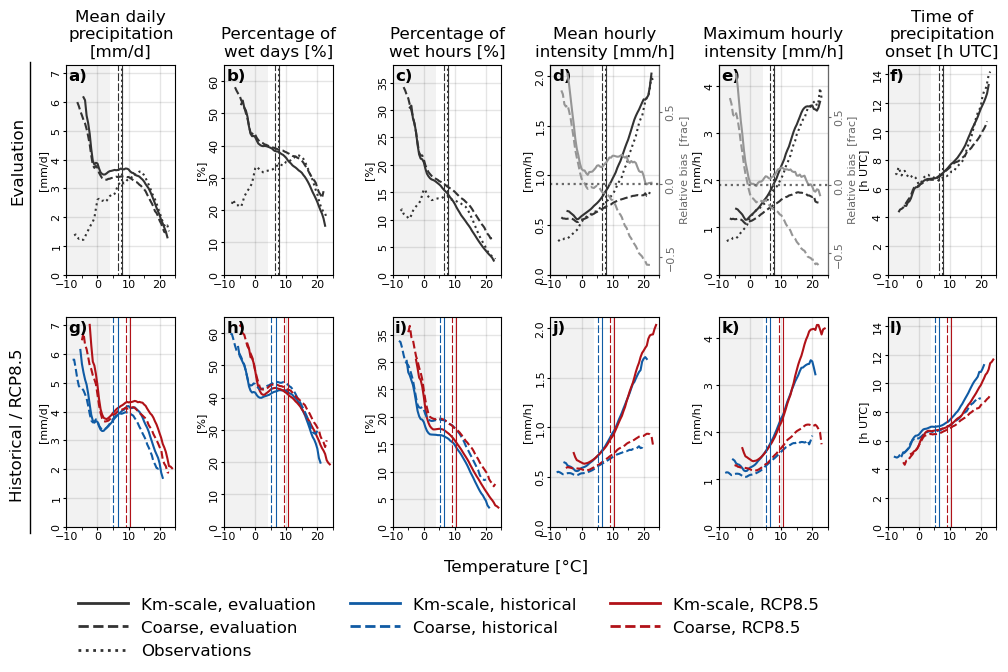

In [55]:
rows = 2

# use gridspec to add whitespace (narrow, empty axes)
gap = 0.45
# second gap bigger: empty space between the daily and the hourly subplots
width_ratios = [1, gap, 1, gap+0.1, 1, gap, 1, gap+0.1, 1, gap+0.1, 1]
gs = mpl.gridspec.GridSpec(2, 11, width_ratios=width_ratios, wspace=0)

# adjust the position of the vertical line between eval/hist/rcp text and units of the first column
for season, x_position_vline, figname in zip(["allseasons", "JJA"][:1], [0.095, 0.09], ["Fig_1", "Fig_S4"]):
    
    # initiate figure without axes
    fig = plt.figure(figsize=[12, 6])

    # create a placeholder array to hold the axes that will be added to the figure according to the gridspec
    axes = np.empty((rows, 6),  dtype=object)
    axes_twinx = np.empty((rows, 6),  dtype=object)
    # we want 4 rows, 6 columns
    for i in range(rows):
        for j in range(6):
            # Skip the empty placeholder axes used to create empty spaces
            gs_col = j * 2

            # If we're in the third row, share y-axis limits with the first row, no sharing otherwise
            if i  == 0:
                share_ax = None
            else: 
                share_ax = axes[0, j]

            # add axis to the figure according to gridspec
            ax = fig.add_subplot(gs[i, gs_col], sharey=share_ax)
            # add the created axis to the axes array
            axes[i, j] = ax
            # create twin axes for the 2nd and 4th row
            if i == 0 and j in [3, 4]:
                axes_twinx[i, j] = ax.twinx()

    # now that axes are created, start plotting
    # FIRST ROW: evaluation
    # 2nd + 3rd column: percentage of wet days and wet hours
    for res, ls in zip(["stations", "kmscale", "driving"], [ls_stations, ls_kmscale, ls_driving]):
        dict_ds_req[f"ds_quantiles_{res}_eval_ddmean_{season}"]["wet_percentage"].plot(ax=axes[0, 1], ls=ls, c=c1_eval)
        dict_ds_req[f"ds_quantiles_{res}_eval_hdmean_{season}"]["wet_percentage"].plot(ax=axes[0, 2], ls=ls, c=c1_eval)

    # Columns 1, 4, 5, 6: mean daily precipitation, mean daily intensity, max daily intensity, time of precipitation onset
    for (v, i) in zip(vars_alldays, [0, 3, 4, 5]):
        for res, ls in zip(["stations", "kmscale", "driving"], [ls_stations, ls_kmscale, ls_driving]):
            dict_ds_req[f"ds_daystats_{res}_eval_dmean_{season}"][v].plot(ax=axes[0, i], ls=ls, color=c1_eval)

        # Only twin axes (intensity)
        if i in [3, 4]:
            for res, ls in zip(["kmscale", "driving"], [ls_kmscale, ls_driving]):
                rel_diff_eval[f"{v}_{res}_{season}"].plot(ax=axes_twinx[0, i], ls=ls, color=c3_eval)

    # SECOND ROW: hist + rcp
    # 2nd + 3rd column: percentage of wet days and wet hours
    for res, ls in zip(["kmscale", "driving"], [ls_kmscale, ls_driving]):
        for period, period_color in zip (['hist', 'rcp'], [c1_hist, c1_rcp]):
            dict_ds_req[f"ds_quantiles_{res}_{period}_ddmean_{season}"]["wet_percentage"].plot(ax=axes[1, 1], ls=ls, c=period_color)
            dict_ds_req[f"ds_quantiles_{res}_{period}_hdmean_{season}"]["wet_percentage"].plot(ax=axes[1, 2], ls=ls, c=period_color)
        
    # Columns 1, 4, 5, 6: mean daily precipitation, mean daily intensity, max daily intensity, time of precipitation onset
    for (v, i) in zip(vars_alldays, [0, 3, 4, 5]):
        dict_ds_req[f"ds_daystats_kmscale_hist_dmean_{season}"][v].plot(ax=axes[1, i], ls=ls_kmscale, color=c1_hist)
        dict_ds_req[f"ds_daystats_driving_hist_dmean_{season}"][v].plot(ax=axes[1, i], ls=ls_driving, color=c1_hist)
        dict_ds_req[f"ds_daystats_kmscale_rcp_dmean_{season}"][v].plot(ax=axes[1, i], ls=ls_kmscale, color=c1_rcp)
        dict_ds_req[f"ds_daystats_driving_rcp_dmean_{season}"][v].plot(ax=axes[1, i], ls=ls_driving, color=c1_rcp)

    # Change axes settings: ranges, ticks, labels, etc
    for ax in axes.flatten():
        if season == "JJA":
            ax.set_xlim(xlim_summer)
        else:
            ax.set_xlim(xlim_allyear)
        ax.set_xlabel("")
        ax.set_ylim(0, None)
        decorate_axis(ax)

    # set titles, x- and y-labels of the columns: others are set before
    for ax, title in zip(axes[0, :], titles_alldays):
        ax.set_title(title) 

    unit_labels = ["[mm/d]", "[%]", "[%]", "[mm/h]", "[mm/h]", "[h UTC]"]
    row_twinx_labels = ["Relative bias  [frac]", ""]
    major_ticks_main = [1, 10, 5, 0.5, 1, 2]
    labelpad = 2.4
    ticklength = 2.25
    tickpad = 1.25
    for col_idx, (unit, tick) in enumerate(zip(unit_labels, major_ticks_main)):
        for row_idx in range(rows):
            # select axis and twin axis
            ax = axes[row_idx, col_idx]
            # add units to each y-axis, set major y-ticks
            ax.set_ylabel(unit, labelpad=labelpad)
            ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=tick))
            ax.tick_params(axis="both", length=ticklength, pad=tickpad)
            ax.tick_params(axis="y", labelrotation=90)
            for label in ax.get_yticklabels():
                label.set_va("center")

            # settings of twin axes
            ax_twinx = axes_twinx[row_idx, col_idx]
            if ax_twinx is not None:
                # add horizontal lines at 0  for relative bias of intensity
                ax_twinx.axhline(y=0, lw=1.6, ls=":", color=c2_eval)
                # set major y-ticks
                ax_twinx.tick_params(axis="both", length=ticklength, pad=tickpad)
                ax_twinx.tick_params(axis="y", colors=c2_eval, labelcolor=c2_eval, labelrotation=90)
                ax_twinx.yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.5))
                ax_twinx.set_ylabel("Relative bias  [frac]", labelpad=labelpad, color=c2_eval)
                for label in ax_twinx.get_yticklabels():
                    label.set_va("center")
                    label.set_ha("left")
                    current_pos = label.get_position()
                    label.set_position((1+tickpad/100, current_pos[1]))
                ax_twinx.spines["right"].set_color(c2_eval)
                # add ylabel only to two columns
                
    # add text to the first column to add Evaluation/Historical/RCP8.5
    x=0.078
    fig.text(x, 0.72, "Evaluation", rotation=90, fontsize=fontsize, va="center")
    fig.text(x, 0.28, "Historical / RCP8.5", rotation=90, fontsize=fontsize, va="center")

    # add vertical line in the left side of the plot
    x = x_position_vline
    fig.add_artist(plt.Line2D([x, x], [0.1, 0.885], transform=fig.transFigure,
                  color='k', linestyle='-', linewidth=1))

    # add subplot labels: letters in the upper left corner
    for ax, letter in zip(axes.flatten(), string.ascii_lowercase):
        ax.text(0.02, 0.98, f"{letter})", transform=ax.transAxes,
        fontweight="bold", va="top")

    # add mean temperature info: vertical line in the corresponding style for all datasets
    longdash = (5, (7, 2))
    for ax in axes[0, :]:
        ax.axvline(x=get_mean_temperature(dict_ds_noreq[f"ds_quantiles_stations_eval_ddmean_{season}"]), color=c1_eval, lw=1.5, ls=":")        
        ax.axvline(x=get_mean_temperature(dict_ds_noreq[f"ds_quantiles_kmscale_eval_ddmean_{season}"]), color=c1_eval, lw=0.8, ls="-")        
        ax.axvline(x=get_mean_temperature(dict_ds_noreq[f"ds_quantiles_driving_eval_ddmean_{season}"]), color=c1_eval, lw=0.8, ls=longdash)        

    for ax in axes[1, :]:
        ax.axvline(x=get_mean_temperature(dict_ds_noreq[f"ds_quantiles_kmscale_hist_ddmean_{season}"]), color=c1_hist, lw=0.8, ls="-")        
        ax.axvline(x=get_mean_temperature(dict_ds_noreq[f"ds_quantiles_driving_hist_ddmean_{season}"]), color=c1_hist, lw=0.8, ls=longdash)        
        ax.axvline(x=get_mean_temperature(dict_ds_noreq[f"ds_quantiles_kmscale_rcp_ddmean_{season}"]), color=c1_rcp, lw=0.8, ls="-")
        ax.axvline(x=get_mean_temperature(dict_ds_noreq[f"ds_quantiles_driving_rcp_ddmean_{season}"]), color=c1_rcp, lw=0.8, ls=longdash)

    # legend
    axes[1, 0].legend(
        handles=handles_all_datasets,
        bbox_to_anchor=[0, -0.28],
        borderpad=0.2,
        ncol=3,
        handlelength=3,
        frameon=False,
        loc="upper left")
    
    fig.supxlabel("Temperature [°C]", y=0.03)
    
    # Add CC-scaling line (7% increase per 1°C) to intensity columns
    x = np.arange(-10, 30, 0.2)
    # # TODO come up with good numbers
    # for row_idx in range(rows):
    #     for y0 in [0.2, 0.4, 0.6, 0.8]:
    #         y = y0 * np.power(1.07, x)
    #         axes[row_idx, 3].plot(x, y, color=c3_eval, linewidth=0.5, ls=(5, (10, 3)), zorder=0)
    #     for y0 in [0.7, 1.0, 1.3, 1.6]:    
    #         y = y0 * np.power(1.07, x)
    #         axes[row_idx, 4].plot(x, y, color=c3_eval, linewidth=0.5, ls=(5, (10, 3)), zorder=0)

    # # save file
    # if savefigs:
    #     fig.savefig(os.path.join(folder_figures, f"{figname}.pdf"),
    #         dpi=200,
    #         bbox_inches="tight",
    #         format="pdf")

## Plot: CC scaling of mean and max intensity

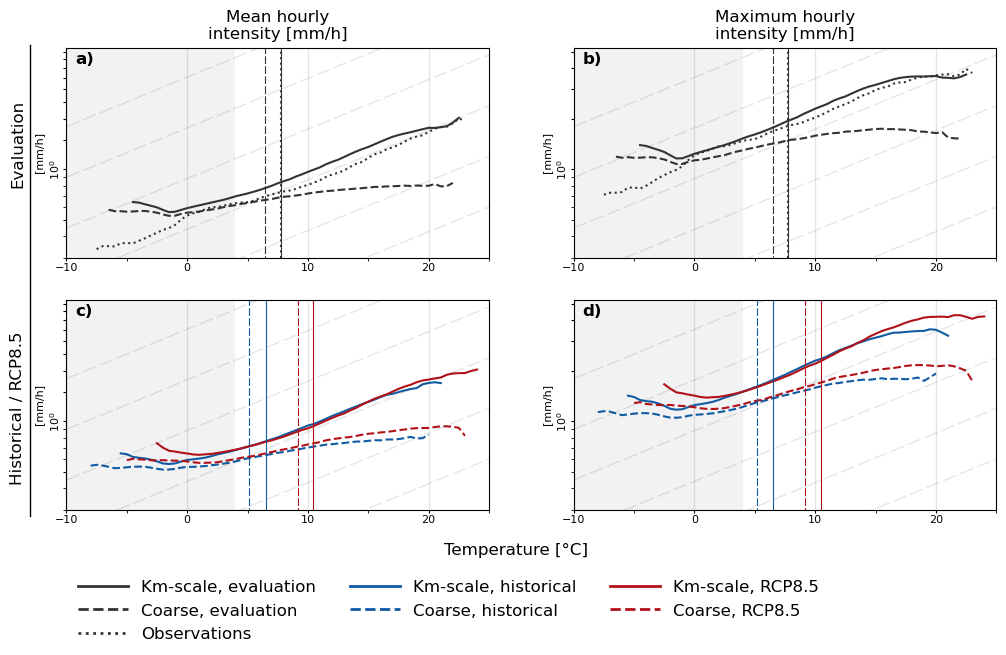

In [29]:
# adjust the position of the vertical line between eval/hist/rcp text and units of the first column
for season, x_position_vline, figname in zip(["allseasons", "JJA"][:1], [0.095, 0.09], ["Fig_1", "Fig_S4"]):
    
    # initiate figure without axes
    fig, axes = plt.subplots(figsize=[12, 6], ncols=2, nrows=2, sharex=True, sharey='col')

    t_bins = dict_ds_req[f"ds_daystats_kmscale_hist_dmean_{season}"].temperature_bin


    # Columns 1, 4, 5, 6: mean daily precipitation, mean daily intensity, max daily intensity, time of precipitation onset
    for (v, i) in zip(vars_alldays[1:3], [0, 1]):
        for res, ls in zip(["stations", "kmscale", "driving"], [ls_stations, ls_kmscale, ls_driving]):
            dict_ds_req[f"ds_daystats_{res}_eval_dmean_{season}"][v].plot(ax=axes[0, i], ls=ls, color=c1_eval)

        dict_ds_req[f"ds_daystats_kmscale_hist_dmean_{season}"][v].plot(ax=axes[1, i], ls=ls_kmscale, color=c1_hist)
        dict_ds_req[f"ds_daystats_driving_hist_dmean_{season}"][v].plot(ax=axes[1, i], ls=ls_driving, color=c1_hist)
        dict_ds_req[f"ds_daystats_kmscale_rcp_dmean_{season}"][v].plot(ax=axes[1, i], ls=ls_kmscale, color=c1_rcp)
        dict_ds_req[f"ds_daystats_driving_rcp_dmean_{season}"][v].plot(ax=axes[1, i], ls=ls_driving, color=c1_rcp)

    # Change axes settings: ranges, ticks, labels, etc
    for ax in axes.flatten():
        ax.set_xlim(xlim_allyear)
        ax.set_xlabel("")
        ax.set_ylim(0.3, 5.3)
        decorate_axis(ax, axis_grid='x')
        add_CC_lines(ax, t_bins, y0=0.02, plot_2CC=False)
        ax.set_yscale('log')

    # set titles, x- and y-labels of the columns: others are set before
    for ax, title in zip(axes[0, :], titles_alldays[3:5]):
        ax.set_title(title) 

    unit_labels = ["[mm/h]", "[mm/h]"]
    major_ticks_main = [ 0.5, 1,]
    labelpad = 2.4
    ticklength = 2.25
    tickpad = 1.25
    for col_idx, (unit, tick) in enumerate(zip(unit_labels, major_ticks_main)):
        for row_idx in range(rows):
            # select axis and twin axis
            ax = axes[row_idx, col_idx]
            # add units to each y-axis, set major y-ticks
            ax.set_ylabel(unit, labelpad=labelpad)
            ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=tick))
            ax.tick_params(axis="both", length=ticklength, pad=tickpad)
            ax.tick_params(axis="y", labelrotation=90)
            for label in ax.get_yticklabels():
                label.set_va("center")

    # add text to the first column to add Evaluation/Historical/RCP8.5
    x=0.078
    fig.text(x, 0.72, "Evaluation", rotation=90, fontsize=fontsize, va="center")
    fig.text(x, 0.28, "Historical / RCP8.5", rotation=90, fontsize=fontsize, va="center")

    # add vertical line in the left side of the plot
    x = x_position_vline
    fig.add_artist(plt.Line2D([x, x], [0.1, 0.885], transform=fig.transFigure,
                  color='k', linestyle='-', linewidth=1))

    # add subplot labels: letters in the upper left corner
    for ax, letter in zip(axes.flatten(), string.ascii_lowercase):
        ax.text(0.02, 0.98, f"{letter})", transform=ax.transAxes,
        fontweight="bold", va="top")

    # add mean temperature info: vertical line in the corresponding style for all datasets
    longdash = (5, (7, 2))
    for ax in axes[0, :]:
        ax.axvline(x=get_mean_temperature(dict_ds_noreq[f"ds_quantiles_stations_eval_ddmean_{season}"]), color=c1_eval, lw=1.5, ls=":")        
        ax.axvline(x=get_mean_temperature(dict_ds_noreq[f"ds_quantiles_kmscale_eval_ddmean_{season}"]), color=c1_eval, lw=0.8, ls="-")        
        ax.axvline(x=get_mean_temperature(dict_ds_noreq[f"ds_quantiles_driving_eval_ddmean_{season}"]), color=c1_eval, lw=0.8, ls=longdash)        

    for ax in axes[1, :]:
        ax.axvline(x=get_mean_temperature(dict_ds_noreq[f"ds_quantiles_kmscale_hist_ddmean_{season}"]), color=c1_hist, lw=0.8, ls="-")        
        ax.axvline(x=get_mean_temperature(dict_ds_noreq[f"ds_quantiles_driving_hist_ddmean_{season}"]), color=c1_hist, lw=0.8, ls=longdash)        
        ax.axvline(x=get_mean_temperature(dict_ds_noreq[f"ds_quantiles_kmscale_rcp_ddmean_{season}"]), color=c1_rcp, lw=0.8, ls="-")
        ax.axvline(x=get_mean_temperature(dict_ds_noreq[f"ds_quantiles_driving_rcp_ddmean_{season}"]), color=c1_rcp, lw=0.8, ls=longdash)

    # legend
    axes[1, 0].legend(
        handles=handles_all_datasets,
        bbox_to_anchor=[0, -0.28],
        borderpad=0.2,
        ncol=3,
        handlelength=3,
        frameon=False,
        loc="upper left")
    
    fig.supxlabel("Temperature [°C]", y=0.03)
    
    # # save file
    # if savefigs:
    #     fig.savefig(os.path.join(folder_figures, f"{figname}.pdf"),
    #         dpi=200,
    #         bbox_inches="tight",
    #         format="pdf")

## Plot: elevation dependence

In [56]:
dict_ds_elevations = {}
elev_bands = [(0, 500), (500, 1000), (1000, 9999), (0, 9999)]
get_mean = True

for elev_band in elev_bands:
    # get string with elevation band borders
    elev_str = f"{elev_band[0]}-{elev_band[1]}"

    # get simple mean: stations
    dict_ds_elevations[f"ds_quantiles_stations_eval_hdmean_allseasons_{elev_str}"] = open_and_prepare_dataset(f"{folder_processed_data}/quantiles_GeoSphere_eval_hdmean_allseasons.nc", apply_req=True, select_vars=True, elev_band=elev_band, get_mean=get_mean, **kwargs_req_quantiles_hours_year)
    dict_ds_elevations[f"ds_quantiles_stations_eval_ddmean_allseasons_{elev_str}"] = open_and_prepare_dataset(f"{folder_processed_data}/quantiles_GeoSphere_eval_ddmean_allseasons.nc", apply_req=True, select_vars=True, elev_band=elev_band, get_mean=get_mean, **kwargs_req_quantiles_days_year)
    dict_ds_elevations[f"ds_daystats_stations_eval_dmean_allseasons_{elev_str}"] = open_and_prepare_dataset(f"{folder_processed_data}/various_daily_stats_GeoSphere_eval_dmean_allseasons.nc", apply_req=True, select_vars=True, elev_band=elev_band, get_mean=get_mean, **kwargs_req_daystats_year)

    # fill with the fraction being applied without taking means (that takes means over all variables which takes ages)
    for res in ["kmscale", "driving"]:
        # get simple mean
        dict_ds_elevations[f"ds_quantiles_{res}_eval_hdmean_allseasons_{elev_str}"] = open_and_prepare_dataset(f"{folder_processed_data}/quantiles_{res}_ensemble_eval_hdmean_allseasons.nc", apply_req=True, select_vars=True, elev_band=elev_band, get_mean=get_mean, **kwargs_req_quantiles_hours_year)
        dict_ds_elevations[f"ds_quantiles_{res}_eval_ddmean_allseasons_{elev_str}"] = open_and_prepare_dataset(f"{folder_processed_data}/quantiles_{res}_ensemble_eval_ddmean_allseasons.nc", apply_req=True, select_vars=True, elev_band=elev_band, get_mean=get_mean, **kwargs_req_quantiles_days_year)
        dict_ds_elevations[f"ds_daystats_{res}_eval_dmean_allseasons_{elev_str}"] = open_and_prepare_dataset(f"{folder_processed_data}/various_daily_stats_{res}_ensemble_eval_dmean_allseasons.nc", apply_req=True, select_vars=True, elev_band=elev_band, get_mean=get_mean, **kwargs_req_daystats_year)


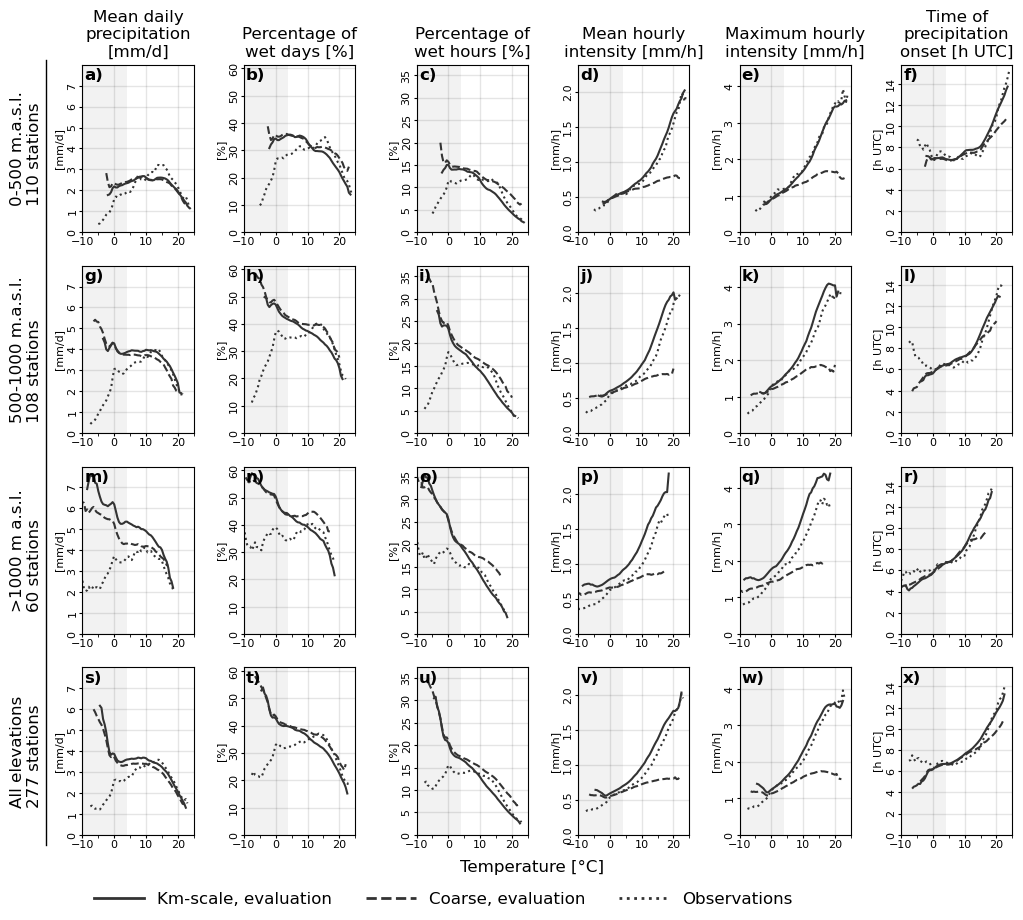

In [57]:
# SUPPLEMENTS: ADDED UPSCALED DATA + ELEVATION DEPENDENCE: EVALUATION ONLY

rows = len(elev_bands)
# use gridspec to add whitespace (narrow, empty axes)
gap = 0.45
# second gap bigger: empty space between the daily and the hourly subplots
width_ratios = [1, gap, 1, gap+0.1, 1, gap, 1, gap, 1, gap, 1]
gs = mpl.gridspec.GridSpec(rows, 11, width_ratios=width_ratios, wspace=0)

# adjust the position of the vertical line between eval/hist/rcp text and units of the first column
for season, x_position_vline, figname in zip(["allseasons", "JJA"][:1], [0.095, 0.09], ["Fig_1", "Fig_S4"]):
    
    # initiate figure without axes
    fig = plt.figure(figsize=[12, 10])

    # create a placeholder array to hold the axes that will be added to the figure according to the gridspec
    axes = np.empty((rows, 6),  dtype=object)
    # we want 5 rows, 6 columns
    for i in range(rows):
        for j in range(6): 
            # Skip the empty placeholder axes used to create empty spaces
            gs_col = j * 2
            # Share y-axis limits with the first row
            if i == 0:
                share_ax = None
            else:
                share_ax = axes[0, j]

            # add axis to the figure according to gridspec
            ax = fig.add_subplot(gs[i, gs_col], sharey=share_ax)
            # add the created axis to the axes array
            axes[i, j] = ax

    # now that axes are created, start plotting
    for row_idx, elev_band in enumerate(elev_bands):
        # get string with elevation band borders
        elev_str = f"{elev_band[0]}-{elev_band[1]}"

        for res, ls in zip(["stations", "kmscale", "driving"], [ls_stations, ls_kmscale, ls_driving]):
            # 2nd + 3rd column: percentage of wet days and wet hours
            dict_ds_elevations[f"ds_quantiles_{res}_eval_ddmean_allseasons_{elev_str}"]["wet_percentage"].plot(ax=axes[row_idx, 1], ls=ls, c=c1_eval)
            dict_ds_elevations[f"ds_quantiles_{res}_eval_hdmean_allseasons_{elev_str}"]["wet_percentage"].plot(ax=axes[row_idx, 2], ls=ls, c=c1_eval)
            # Columns 1, 4, 5, 6: mean daily precipitation, mean daily intensity, max daily intensity, time of precipitation onset
            for (v, i) in zip(vars_alldays, [0, 3, 4, 5]):
                dict_ds_elevations[f"ds_daystats_{res}_eval_dmean_allseasons_{elev_str}"][v].plot(ax=axes[row_idx, i], ls=ls, color=c1_eval)

    # Change axes settings: ranges, ticks, labels, etc
    for ax in axes.flatten():
        if season == "JJA":
            ax.set_xlim(xlim_summer)
        else:
            ax.set_xlim(xlim_allyear)
        ax.set_xlabel("")
        decorate_axis(ax)
        ax.set_ylim(0, None)

    # set titles, x- and y-labels of the columns: others are set before
    for ax, title in zip(axes[0, :], titles_alldays):
        ax.set_title(title) 

    unit_labels = ["[mm/d]", "[%]", "[%]", "[mm/h]", "[mm/h]", "[h UTC]"]
    major_ticks_main = [1, 10, 5, 0.5, 1, 2]
    labelpad = 2.35
    ticklength = 2.25
    tickpad = 1.25

    for col_idx, (unit, tick) in enumerate(zip(unit_labels, major_ticks_main)):
        for ax in axes[:, col_idx].flatten():
            ax.set_ylabel(f"{unit}", labelpad=labelpad)
            ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=tick))
            ax.tick_params(axis="both", length=ticklength, pad=tickpad)
            ax.tick_params(axis="y", labelrotation=90)

            for label in ax.get_yticklabels():
                label.set_va("center")

    for row_idx, elev_band in enumerate(elev_bands):
        # get string with elevation band borders
        elev_str = f"{elev_band[0]}-{elev_band[1]}"

        if elev_band == (0, 9999):
            row_label = "All elevations"
        elif elev_band[1] == 9999:
            row_label = f">{elev_band[0]} m a.s.l."
        else:
            row_label = f"{elev_band[0]}-{elev_band[1]} m.a.s.l."

        num_stations = dict_ds_elevations[f"ds_daystats_stations_eval_dmean_allseasons_{elev_str}"].num_stations
        # select axis
        ax = axes[row_idx, 0]
        ax.text(-0.65, ax.yaxis.get_label().get_position()[1], f'{row_label}\n{num_stations} stations', 
                rotation=90, fontsize=fontsize, va="center", transform=ax.transAxes)

    fig.supxlabel("Temperature [°C]", y=0.07)

    # add vertical line in the left side of the plot
    x = x_position_vline
    fig.add_artist(plt.Line2D([x, x], [0.1, 0.885], transform=fig.transFigure,
                  color='k', linestyle='-', linewidth=1))

    # add subplot labels: letters in the upper left corner
    for ax, letter in zip(axes.flatten(), string.ascii_lowercase):
        ax.text(0.02, 0.98, f"{letter})", transform=ax.transAxes,
        fontweight="bold", va="top")

    # legend
    axes[-1, 0].legend(
        handles=handles_all_datasets[:3],
        bbox_to_anchor=[0, -0.27],
        borderpad=0.2,
        ncol=3,
        handlelength=3,
        frameon=False,
        loc="upper left")
    
    # for col, y0 in zip([3, 4], [0.5, 1.2]):
    #     for ax in axes[:, col].flatten():
    #         x = np.arange(-10, 30, 0.2)
    #         y = y0 * np.power(1.07, x)
    #         ax.plot(x, y, color=c3_eval, linewidth=1, ls="-", zorder=0)

    # # save file
    # if savefigs:
    #     fig.savefig(os.path.join(folder_figures, f"{figname}.pdf"),
    #         dpi=200,
    #         bbox_inches="tight",
    #         format="pdf")

# Figure 2, Figure S5: precipitation statistics separated by daily precipitation sums

## Functions and definitions

In [58]:
# datasets without requirements
ds_stations_eval_noreq = dict_ds_noreq['ds_daystats_stations_eval_dmean_allseasons']
ds_kmscale_eval_noreq = dict_ds_noreq['ds_daystats_kmscale_eval_dmean_allseasons']
ds_driving_eval_noreq = dict_ds_noreq['ds_daystats_driving_eval_dmean_allseasons']

ds_kmscale_hist_noreq = dict_ds_noreq['ds_daystats_kmscale_hist_dmean_allseasons']
ds_driving_hist_noreq = dict_ds_noreq['ds_daystats_driving_hist_dmean_allseasons']

ds_kmscale_rcp_noreq = dict_ds_noreq['ds_daystats_kmscale_rcp_dmean_allseasons']
ds_driving_rcp_noreq = dict_ds_noreq['ds_daystats_driving_rcp_dmean_allseasons']

# apply requirements to all datasets, get mean over stations and models
ds_stations_eval_req = dict_ds_req['ds_daystats_stations_eval_dmean_allseasons']
ds_kmscale_eval_req = dict_ds_req['ds_daystats_kmscale_eval_dmean_allseasons']
ds_driving_eval_req = dict_ds_req['ds_daystats_driving_eval_dmean_allseasons']

ds_kmscale_hist_req = dict_ds_req['ds_daystats_kmscale_hist_dmean_allseasons']
ds_driving_hist_req = dict_ds_req['ds_daystats_driving_hist_dmean_allseasons']

ds_kmscale_rcp_req = dict_ds_req['ds_daystats_kmscale_rcp_dmean_allseasons']
ds_driving_rcp_req = dict_ds_req['ds_daystats_driving_rcp_dmean_allseasons']

## Plots

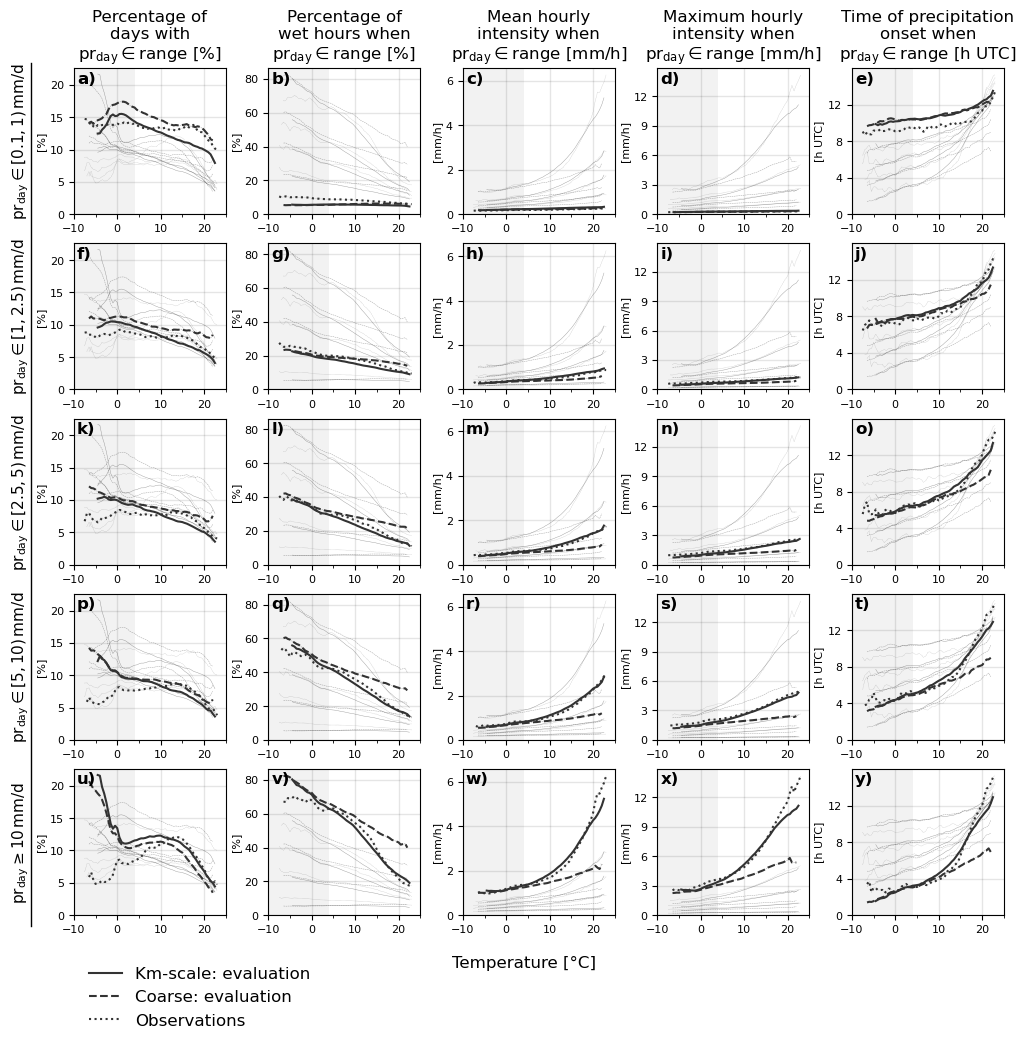

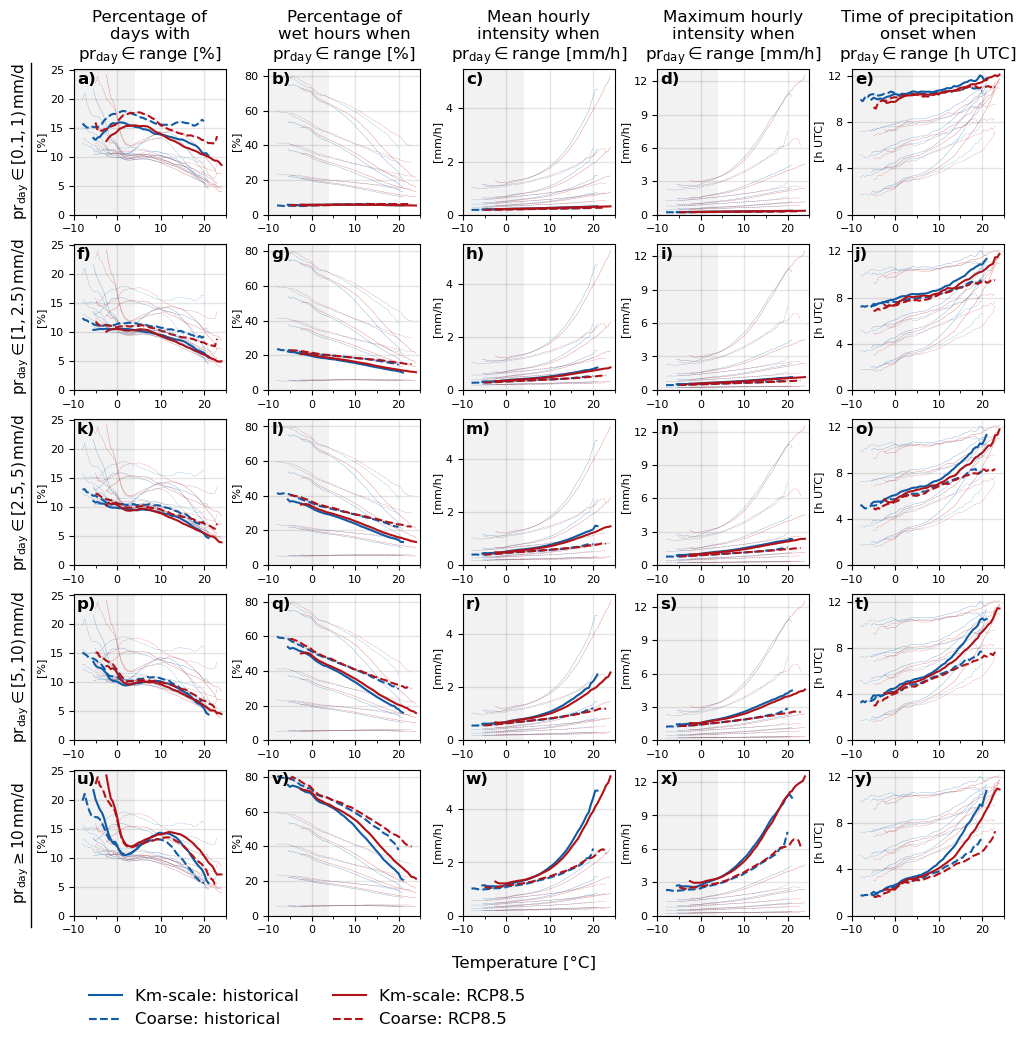

In [59]:
figsize = [12, 11]

fig_eval, axes_eval = plt.subplots(
    nrows=len(dict_pr_ranges),
    ncols=len(vars_separated),
    sharey='col',
    sharex=True,
    figsize=figsize,
)

fig_histrcp, axes_histrcp = plt.subplots(
    nrows=len(dict_pr_ranges),
    ncols=len(vars_separated),
    sharey='col',
    sharex=True,
    figsize=figsize,
)

alpha = 0.5
lw_thin = 0.3
plot_thin_lines = True

# create tuples with axes for each dataset in them and other relevant data for the plot specific to each dataset
# this has to be created after the figures are initiated -> axes exist
datasets = [
    (ds_kmscale_eval_req,  ds_kmscale_eval_noreq,  ls_kmscale,  c1_eval, c2_eval, c3_eval, axes_eval,    'Km-scale: evaluation'),
    (ds_driving_eval_req,  ds_driving_eval_noreq,  ls_driving,  c1_eval, c2_eval, c3_eval, axes_eval,    'Coarse: evaluation'),
    (ds_stations_eval_req, ds_stations_eval_noreq, ls_stations, c1_eval, c2_eval, c3_eval, axes_eval,    'Observations'),
    (ds_kmscale_hist_req,  ds_kmscale_hist_noreq,  ls_kmscale,  c1_hist, c2_hist, c3_hist, axes_histrcp, 'Km-scale: historical'),
    (ds_driving_hist_req,  ds_driving_hist_noreq,  ls_driving,  c1_hist, c2_hist, c3_hist, axes_histrcp, 'Coarse: historical'),
    (ds_kmscale_rcp_req,   ds_kmscale_rcp_noreq,   ls_kmscale,  c1_rcp,  c2_rcp,  c3_rcp,  axes_histrcp, 'Km-scale: RCP8.5'),
    (ds_driving_rcp_req,   ds_driving_rcp_noreq,   ls_driving,  c1_rcp,  c2_rcp,  c3_rcp,  axes_histrcp, 'Coarse: RCP8.5'),
    ]

for r_idx, (r, r_label) in enumerate(zip(dict_pr_ranges.keys(), dict_pr_ranges.values())):
    for v_idx, v in enumerate(vars_separated):
        var_full = f'{v}_{r}'
        for (ds, ds_noreq, ls, c_primary, c_daily, c_hourly, axes, label) in datasets:
            dims = [dim for dim in ['model', 'station_name'] if dim in ds.dims]

            # plot the percentage of wet days: fraction of range count to all days
            if v == 'pr_range_frequency':
                (100 * ds[f'pr_range_count_{r}'] / ds['daily_count']).plot(ax=axes[r_idx, v_idx], ls=ls, lw=None, c=c_primary, alpha=1, label=label)

                if plot_thin_lines:
                    for ax in axes[:, v_idx]:
                        (100 * ds[f'pr_range_count_{r}'] / ds['daily_count']).plot(ax=ax, ls=ls, lw=lw_thin, c=c_primary, alpha=alpha)

            # plot the percentage of wet hours
            elif v == 'wet_hour_count':
                # fraction of wet hours calculated as count per day / 24, then multiplied by 100 to get percentage
                (ds[var_full] / 24 * 100).plot(ax=axes[r_idx, v_idx], ls=ls, lw=None, c=c_primary) 
                if plot_thin_lines:
                    for ax in axes[:, v_idx]:
                        (ds[var_full] / 24 * 100).plot(ax=ax, ls=ls, lw=lw_thin, c=c_primary, alpha=alpha) 

            # plot all other variables: mean/maximum intensity, time of precipitation onset
            else:
                ds[var_full].mean(dim=dims).plot(ax=axes[r_idx, v_idx], ls=ls, c=c_primary)
                if plot_thin_lines:
                    for ax in axes[:, v_idx]:
                        ds[var_full].mean(dim=dims).plot(ax=ax, ls=ls, c=c_primary, lw=lw_thin, alpha=alpha)

# axes settings etc of both figures
for axes in [axes_eval, axes_histrcp]:
    for ax in axes.flatten():
        ax.set_xlim(xlim_allyear)
        ax.set_ylim(0, None)
        ax.set_xlabel('')   
        decorate_axis(ax)

    # set ticks + labels for both figures
    # y-axis labels
    major_ticks = [5, 20, 2, 3, 4]
    unit_labels = ['[%]', '[%]', '[mm/h]', '[mm/h]', '[h UTC]']
    pr_range_labels = [
        '$\\in [0.1, 1)\\,mm/d$',
        '$\\in [1, 2.5)\\,mm/d$',
        '$\\in [2.5, 5)\\,mm/d$',
        '$\\in [5, 10)\\,mm/d$', 
        '$\\geq 10\\,mm/d$'
    ]    
    
    for ax_idx, (unit, tick) in enumerate(zip(unit_labels, major_ticks)):
        for ax, pr_range in zip(axes[:, ax_idx], pr_range_labels):
            # add units to each y-axis
            ax.set_ylabel(unit, labelpad=2.5)
            ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=tick))

    for ax, pr_range in zip(axes[:, 0], pr_range_labels):
        # determine text for the y-axis
        text = '$pr_{day}$'+f'{pr_range}'
        # add labels and/or units to each y-axis
        ax.text(-0.42, 0.5, text, rotation=90, transform=ax.transAxes, va='center', fontsize=fontsize-1)

    # column titles
    axes[0, 0].set_title('Percentage of\ndays with\n$pr_{day} \\in range$ [%]')
    axes[0, 1].set_title('Percentage of\nwet hours when\n$pr_{day} \\in range$ [%]')
    axes[0, 2].set_title('Mean hourly\nintensity when\n$pr_{day} \\in range$ [mm/h]')
    axes[0, 3].set_title('Maximum hourly\nintensity when\n$pr_{day} \\in range$ [mm/h]')
    axes[0, 4].set_title('Time of precipitation\nonset when\n$pr_{day} \\in range$ [h UTC]')

    # add subplot labels: letters in the upper left corner
    for ax, letter in zip(axes.flatten(), string.ascii_lowercase+string.ascii_uppercase):
        ax.text(0.02, 0.98, f'{letter})', transform=ax.transAxes,
            fontweight='bold', va='top')

# add legend: different number of columns for the two figures
axes_eval[-1, 0].legend(frameon=False, loc='upper left', bbox_to_anchor=[0, -0.25], ncols=1)
axes_histrcp[-1, 0].legend(frameon=False, loc='upper left', bbox_to_anchor=[0, -0.4], ncols=2)

for fig in [fig_eval, fig_histrcp]:
    # add x-axis label
    fig.supxlabel("Temperature [°C]", y=0.06)
    # fix white space between subplots to avoid overlapping labels
    fig.subplots_adjust(wspace=0.28)
    # add vertical line in the left side of the plot
    x = 0.089
    fig.add_artist(plt.Line2D([x, x], [0.1, 0.885], transform=fig.transFigure,
                  color='k', linestyle='-', linewidth=1))

if savefigs:
    fig_eval.savefig(os.path.join(folder_figures, 'Fig_2.pdf'),
             dpi=200,
             bbox_inches='tight',
             format='pdf')
    fig_histrcp.savefig(os.path.join(folder_figures, 'Fig_S5.pdf'),
             dpi=200,
             bbox_inches='tight',
             format='pdf')

# Figure 3: CC Scaling

## Functions

In [ ]:
# def plot_scaling(ds, ax, variable_prcp='prcp_percentiles_all', colors=None, lw=2, q_min=0.99):
#     """
#     Plot the scaling of high hourly precipitation percentiles against mean daily temperature.

#     Args:
#         ds (xr.Dataset): dataset containing the precipitation percentiles as a function of temperature
#             (the "qunatiles" files in our case)
#         ax (mpl.axes.Axes): axis to plot the scaling on
#         variable_prcp (str, optional): Variable where the percentiles are stored. Defaults to 'prcp_percentiles_all'.
#         colors (list, optional): List of strings: color hex codes. Defaults to None.
#         lw (int, optional): Linewidth for lines to be plotted. The evaluation lines are supposed to be a bit 
#             thicker in the plot than historical/rcp lines. Defaults to 2.
#         q_min (optional): Lowest quantile to plot, although even lower quantiles might have been calculated
#     """

#     # select variable
#     ds_var = ds[variable_prcp]

#     # start at a given quantile, higher or equal to q_min
#     ds_var = ds_var.sel(quantiles=ds_var.quantiles[ds_var.quantiles >= q_min])       

#     # loop through percentiles, only 0.9 and higher           
#     for q_idx, (q ,c) in enumerate(zip(ds_var.quantiles, colors)):  
#         # add means to the plot, label those with the corresponding q
#         ax.plot(ds_var.temperature_bin, ds_var[:, q_idx], lw=lw, color=c, label=f'p{q*100:.1f}')

#     return    

In [61]:
def plot_CC_figure(
    ds_stations_hd_eval, ds_kmscale_hd_eval, ds_driving_hd_eval,
    ds_kmscale_hd_hist, ds_driving_hd_hist,
    ds_kmscale_hd_rcp, ds_driving_hd_rcp,
    lw=2,
    ):
    """
    Produces the Clausius-Clapeyron scaling figure of hourly precipitation versus mean daily temperature

    Args:
        ds_stations_hd_eval, ds_kmscale_hd_eval, ds_driving_hd_eval, ds_kmscale_hd_hist, ds_driving_hd_hist, 
        ds_kmscale_hd_rcp, ds_driving_hd_rcp (xr.Dataset): All input datasets with hourly precipitation 
            quantiles as a function of mean daily temperature
        q_min (float, optional): Lowest quantile to plot, although even lower quantiles might 
            have been calculated. Defaults to 0.9.
        lw (int, optional): Linewidth for the evaluation lines which are supposed to be a bit thicker 
            in the plot than historical/rcp lines. Defaults to 2.

    Returns:
        fig (mpl.Figure): figure object
        axes (np.array): array of axes plotted in the figure
    """

    # initiate figure
    fig, axes=plt.subplots(
        ncols=3, 
        nrows=1,
        sharex=True,
        sharey=True,
        dpi=200,
        figsize=[12, 4]
        )

    # plot scaling: quantiles over stations and models/stations
    plot_scaling(ds_kmscale_hd_rcp, axes[1], colors=colors_rcp, lw=1)
    plot_scaling(ds_driving_hd_rcp, axes[2], colors=colors_rcp, lw=1)

    plot_scaling(ds_kmscale_hd_hist, axes[1], colors=colors_hist, lw=1)
    plot_scaling(ds_driving_hd_hist, axes[2], colors=colors_hist, lw=1)

    # use a thicker linewidth for evaluation to emphasize it
    plot_scaling(ds_stations_hd_eval, axes[0], colors=colors_eval, lw=lw)
    plot_scaling(ds_kmscale_hd_eval, axes[1], colors=colors_eval, lw=lw)
    plot_scaling(ds_driving_hd_eval, axes[2], colors=colors_eval, lw=lw)

    # temperature bins, used as the x-axis coordinate
    t_bins = ds_kmscale_hd_eval.temperature_bin

    # All axes: change x-extent, set x-axis ticks, etc
    for ax in axes:
        add_CC_lines(ax, t_bins)
        ax.grid(which='major', axis='x', lw=1, c='k', ls="-", alpha=alpha_grid)
        ax.set_yscale('log')
        ax.set_ylim(0.7, 40)
        ax.set_xlim(xlim_allyear)
        decorate_axis(ax, axis_grid='x')
        
    # set names of each row + column based on dataset
    axes[0].set_title('Observations')
    axes[1].set_title('Km-scale ensemble')
    axes[2].set_title('Coarse-scale ensemble')

    # add subplot labels: letters in the upper left corner
    for ax, letter in zip(axes.flatten(), string.ascii_lowercase):
        ax.text(0.02, 0.98, f'{letter})', transform=ax.transAxes, fontweight='bold', va='top')

    return fig, axes

## Plots

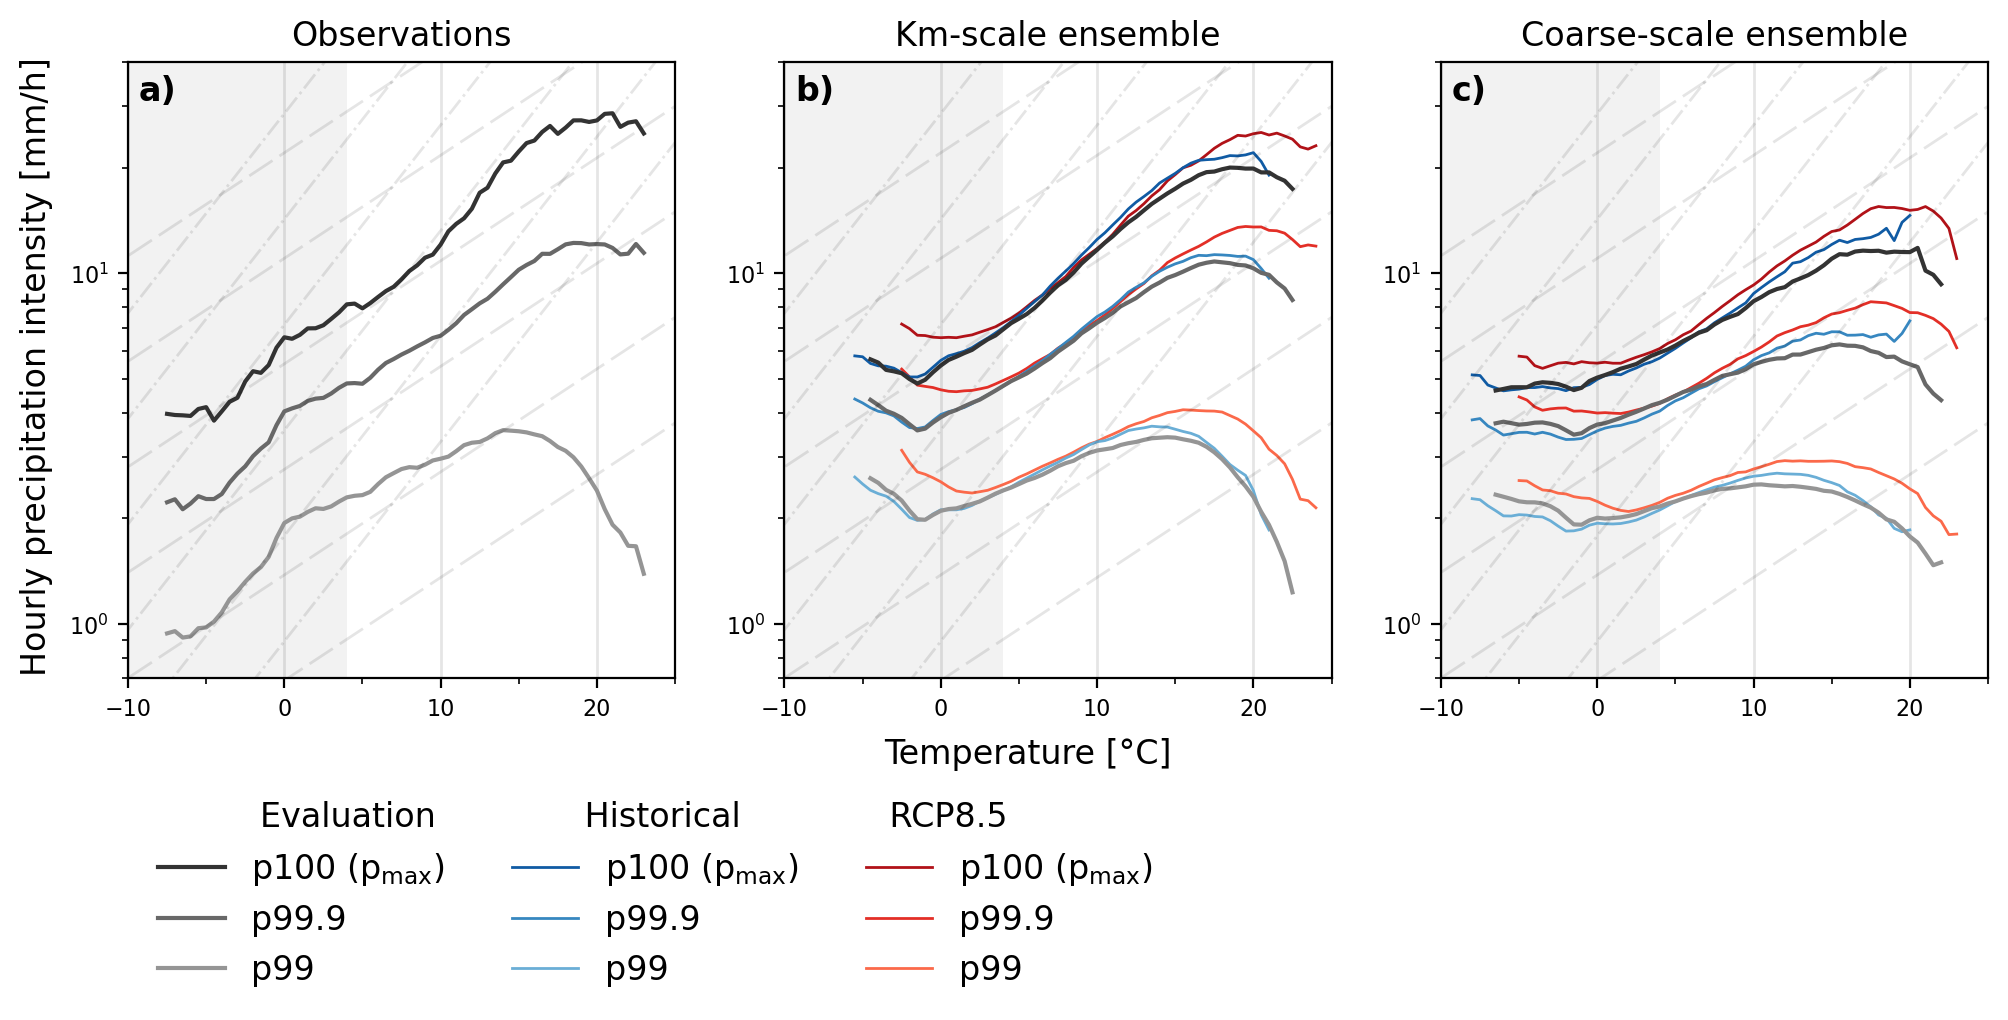

In [62]:
fig, axes = plot_CC_figure(
    dict_ds_req['ds_quantiles_stations_eval_hdmean_allseasons'], 
    dict_ds_req['ds_quantiles_kmscale_eval_hdmean_allseasons'],
    dict_ds_req['ds_quantiles_driving_eval_hdmean_allseasons'],
    dict_ds_req['ds_quantiles_kmscale_hist_hdmean_allseasons'],
    dict_ds_req['ds_quantiles_driving_hist_hdmean_allseasons'],
    dict_ds_req['ds_quantiles_kmscale_rcp_hdmean_allseasons'],
    dict_ds_req['ds_quantiles_driving_rcp_hdmean_allseasons'],        
    lw=1.5,
    )

# add shared x and y axis labels
fig.supxlabel("Temperature [°C]", y=-0.005)
fig.supylabel('Hourly precipitation intensity [mm/h]', x=0.08)

# create legend specifically for this figure
handles, labels = axes[1].get_legend_handles_labels()
labels = [lbl.replace('.0', '') + ' ($p_{max}$)' if '100' in lbl else lbl.replace('.0', '') for lbl in labels]
space = ' ' * 14

legend = axes[0].legend(
    reversed(handles),
    reversed(labels),
    frameon=False,
    bbox_to_anchor=(0, -0.15),
    loc="upper left",
    ncol=3,
    title="Evaluation" + space + "Historical" + space + "RCP8.5    ",
)

if savefigs:
    fig.savefig(os.path.join(folder_figures, 'Fig_3.pdf'),
        dpi=200,
        bbox_inches='tight',
        format='pdf')    

# Figure S1: Map and elevation distribution

## Functions and definitions

In [ ]:
# def get_nearest_neighbor_point(ds, station_lon, station_lat, lon_coord='lon', lat_coord='lat'):
#     """Given a longitude/latitude coordinate pair, find the gridcell with the lowest
#     Euclidean distance to this point. Extract the longitude and latitude of this grid
#     cell and the elevation of this point in the orography file

#     Args:
#         ds (xr.Dataset): Orography file from which we want to extract the staiton locations
#         station_lon (float): Longitude of the actual weather station
#         station_lat (float): Latitude of the actual weather station
#         lon_coord (str, optional): Name of the longitude coordinate in the orography file. Defaults to 'lon'.
#         lat_coord (str, optional): Name of the latitude coordinate in the orography file. Defaults to 'lat'.

#     Returns:
#         point_coords (dict): dictionary holding the latitude, longitude, and elevation of 
#             the station in the orog file based on the nearest neighbor grid cell
#     """

#     # get euclidean distance from all grid points to the desired station lon/lat
#     centered_lon = ds[lon_coord] - station_lon
#     centered_lat = ds[lat_coord] - station_lat
#     euclidean_distance = centered_lon**2 + centered_lat**2

#     # select the point with the lowest euclidean distance
#     nearest_point = euclidean_distance.where(euclidean_distance == np.min(euclidean_distance), drop=True).squeeze()

#     # get elevation at that point (from orog)
#     elevation = ds['orog'].where(euclidean_distance == np.min(euclidean_distance), drop=True).squeeze()

#     # get the position of the nearest neighbor of the station in all available coordinates
#     coords = list(nearest_point.coords)
#     coords = [c for c in coords if c not in ['time', 'bin']]
    
#     # get lat/lon or whatever the coordinates are called
#     point_coords = {}
#     for c in coords:
#         point_coords[c] = nearest_point[c].item() 

#     # print(point_coords)
#     point_coords['elevation'] = elevation

#     return point_coords


In [64]:
# create a dataset with station + kmscale + coarse data: lat, lon, elevation
# number of stations
num_stations = len(ds_stations.station_name)

# list of variables to store in an array
variables = [
    'station_lon', 'station_lat', 'station_elevation', 
    'kmscale_lon', 'kmscale_lat', 'kmscale_elevation', 
    'driving_lon', 'driving_lat', 'driving_elevation'
    ]
# create an empty array for the 9 variables
array_to_fill = np.zeros((num_stations, 9))

# loop through the stations, fill the array
for i in range(num_stations):
    # select the station
    station = ds_stations.isel(station_name=i)
    # get the corresponding coords and elevation from the km-scale and orog files
    nn_coords_kmscale = get_nearest_neighbor_point(ds_orog_kmscale, station["lon"], station["lat"])
    nn_coords_driving = get_nearest_neighbor_point(ds_orog_driving, station["lon"], station["lat"])

    # fill the array
    array_to_fill[i, 0] = station['lon']
    array_to_fill[i, 1] = station['lat']
    array_to_fill[i, 2] = station['elevation']
    array_to_fill[i, 3] = nn_coords_kmscale['lon']
    array_to_fill[i, 4] = nn_coords_kmscale['lat']
    array_to_fill[i, 5] = nn_coords_kmscale['elevation']
    array_to_fill[i, 6] = nn_coords_driving['lon']
    array_to_fill[i, 7] = nn_coords_driving['lat']
    array_to_fill[i, 8] = nn_coords_driving['elevation']

# combine into a dataset with those 9 variables
ds_orog_datasets = xr.DataArray(
    array_to_fill,
    coords={'station_name': ds_stations.station_name, 'variable': variables},
    dims=[ 'station_name', 'variable']
).to_dataset(dim='variable')

## Plots

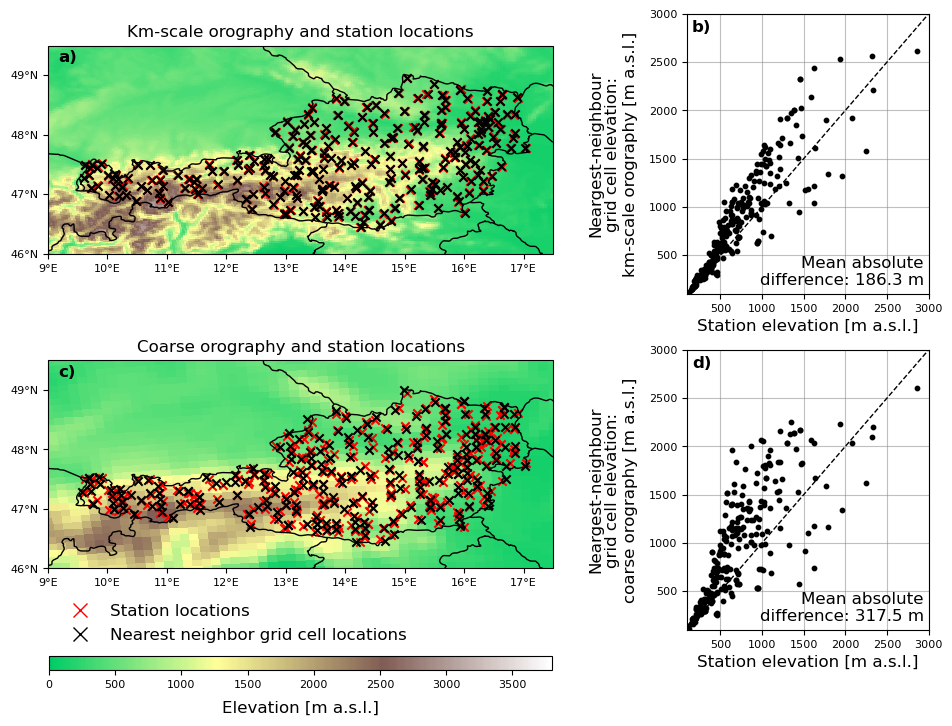

In [65]:
# FIGURE INITIATION
# Initiate figure with 2x2 grid, explicitly create the 4 axes, applying projection only to the top row
fig = plt.figure(figsize=[12, 8])
gs = fig.add_gridspec(2, 2, width_ratios=[2.5, 1], wspace=0.2, hspace=0.2)

# map plots
ax0 = fig.add_subplot(gs[0, 0], **map_subplot_kw) 
ax1 = fig.add_subplot(gs[1, 0], **map_subplot_kw)

# scatter plots
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 1])

# PLOT THE MAPS (axes[0] and axes[1])
# Plot orographies, map kwargs defined above
kmscale_plot = ds_orog_kmscale.orog.plot(ax=ax0, **map_kwargs)
driving_plot = ds_orog_driving.orog.plot(ax=ax1, **map_kwargs)

# Plot station locations
ax0.scatter(ds_orog_datasets.station_lon, ds_orog_datasets.station_lat, color="r", marker="x", transform=ccrs.PlateCarree())
ax0.scatter(ds_orog_datasets.kmscale_lon, ds_orog_datasets.kmscale_lat, color="k", marker="x", transform=ccrs.PlateCarree())
ax1.scatter(ds_orog_datasets.station_lon, ds_orog_datasets.station_lat, color="r", marker="x", transform=ccrs.PlateCarree())
ax1.scatter(ds_orog_datasets.driving_lon, ds_orog_datasets.driving_lat, color="k", marker="x", transform=ccrs.PlateCarree())

# PLOT THE SCATTER PLOTS (axes[2] and axes[3])
# Plot 3+4: km-scale vs station elevation, driving vs station elevation
ax2.scatter(ds_orog_datasets.station_elevation, ds_orog_datasets.kmscale_elevation, markersize, color='k', zorder=3)
ax3.scatter(ds_orog_datasets.station_elevation, ds_orog_datasets.driving_elevation, markersize, color='k', zorder=3)

# add text: mean absolute difference (MAD) between station and model data elevations
mad_kmscale = np.mean(np.abs(ds_orog_datasets.kmscale_elevation - ds_orog_datasets.station_elevation))
mad_driving = np.mean(np.abs(ds_orog_datasets.driving_elevation - ds_orog_datasets.station_elevation))

# FORMATTING AND LABELS
# Add letters and cartopy features to maps
for ax, letter in zip([ax0, ax1], ['a', 'c']):
    ax.text(0.02, 0.98, f'{letter})', transform=ax.transAxes,
    fontweight='bold', va='top')
    ax.coastlines()
    ax.add_feature(cartopy.feature.BORDERS)
    # Set ticks explicitly on the GeoAxes
    ax.set_xticks(np.arange(9, 18, 1), crs=ccrs.PlateCarree())
    ax.set_yticks(np.arange(46, 50, 1), crs=ccrs.PlateCarree())
    # Apply formatting (°E/°W/°N/°S)
    ax.xaxis.set_major_formatter(LongitudeFormatter())
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    # remove labels
    ax.set_xlabel('')
    ax.set_ylabel('')

# Add letters and formatting to scatter plots
for ax, letter, mad in zip([ax2, ax3], ['b', 'd'], [mad_kmscale, mad_driving]):
    # Add text to subplots
    ax.text(0.02, 0.98, f'{letter})', transform=ax.transAxes,
    fontweight='bold', va='top')
    # Set axis limits + optionally also scale
    ax.set_xlim(100, 3000)
    ax.set_ylim(100, 3000)
    # Add 1:1 line and grid
    ax.axline((10, 10), (3000, 3000), c='k', lw=1, ls='--')
    ax.grid(c='gray', alpha=0.5, zorder=-1)
    # Set x labels (shared)
    ax.set_xlabel('Station elevation [m a.s.l.]', fontsize=fontsize)
    # add MAD text
    ax.text(
        0.98, 0.02,     # X, Y coords of text
        f"Mean absolute\ndifference: {mad:.1f} m",
        fontsize=fontsize,
        ha='right', va='bottom',
        transform=ax.transAxes,
    )

# Set titles for the maps
ax0.set_title('Km-scale orography and station locations', fontsize=fontsize)
ax1.set_title('Coarse orography and station locations', fontsize=fontsize)
# Set Y labels for scatter plots
ax2.set_ylabel('Neargest-neighbour\ngrid cell elevation:\nkm-scale orography [m a.s.l.]', fontsize=fontsize, labelpad=8)
ax3.set_ylabel('Neargest-neighbour\ngrid cell elevation:\ncoarse orography [m a.s.l.]', fontsize=fontsize, labelpad=8)

# Apply the shifted position to ax0 and ax1, maintaining width and height
for ax, shift in zip([ax0, ax1], [0.02, 0.07]):
    # Get the original Bbox (normalized figure coordinates)
    bbox = ax.get_position()
    # Set position - adjust only vertical coordinate
    ax.set_position([
        bbox.x0,          # left (x0) remains the same
        bbox.y0 - shift,  # bottom (y0) is shifted down
        bbox.width,       # width remains the same
        bbox.height       # height remains the same
    ])

# COLORBAR AND LEGEND (FIGURE LEVEL)
# Add colorbar to both map plots (ax0 and ax1)
cbar = fig.colorbar(
    kmscale_plot, 
    ax=[ax0, ax1],
    aspect=35, 
    pad=0.14,
    fraction=0.023,
    orientation='horizontal'
)
cbar.set_label("Elevation [m a.s.l.]", fontsize=fontsize, labelpad=8)

# Create legend handles and labels
legend_handles = [
    mpl.lines.Line2D([0], [0], marker='x', color='r', markersize=markersize, linestyle='None'),
    mpl.lines.Line2D([0], [0], marker='x', color='k', markersize=markersize, linestyle='None')
]
legend_labels = ['Station locations', 'Nearest neighbor grid cell locations']

# Add legend, placed near the bottom map plot (ax1) or below the entire top row
ax1.legend(
    handles=legend_handles, 
    labels=legend_labels,
    loc='upper left', 
    bbox_to_anchor=(0, -0.1), # Fine-tune position relative to ax1
    ncol=1,
    frameon=False,
    fontsize=fontsize
)

# SAVE FIGURE
if savefigs:
    fig.savefig(os.path.join(folder_figures, "Fig_S1.pdf"),
        dpi=200,
        bbox_inches="tight",
        format="pdf")

# Figure S2, Figure S3, Figure S6: Temperature distributions

## Functions

In [ ]:
# def plot_normalized_frequency_step(ds, ax, ls='-', color_primary='k', color_secondary='gray', normalization_factor=2):
#     """
#     Plot of the temperature distributions, and of wet hour/day distributions.
#     For simplicity of reading, only every second temperature bin is plotted - the temperature bins
#     are overlapping anyway, which would lead to double-counting. This way each value is shown
#     only once instead of twice.

#     There is a different total number of days in each dataset: some stations have up to 30
#     years of data, but all models have exactly 10 years of data. We therefore need to normalize
#     the temperature distributions for comparability.
#     Since the bins are overlapping, the spacing of the x-axis is 0.5 degrees C - thus, the default
#     normalization factor is 2 to account for this spacing: naively integrating the area under the 
#     curve with dx=0.5 would yield an area of 0.5 instead of 1. With this normalization factor, all 
#     days/hours datasets would be correctly normalized to 1, which would be equivalent to a probability 
#     density function (PDF) of temperature in the dataset. The wet/days hours are normalized by 
#     the total number of days, which yields a "joint PDF" with an area smaller than the PDF of all
#     days.

#     In the publication figures we chose a normalization factor of 2 * 365 for days (and 2*365*24 
#     for hours), which then shows the average number of days *per year* in each temperature bin.
#     The "2" again accounts for the overlapping bins, and the 365 for the number of days in a year.
#     For seasons, we divide these by 4, neglecting the slightly different number of days in each season.

#     This normalization is correct, I checked multiple times.

#     Args:
#         ds (xr.Dataset): Dataset with the count of all/wet hours/days. In this notebook it's the 
#         "quantile" files.
#         ax (mpl.axes.Axes): axis to plot the lines on.
#         ls (str, optional): Linestyle. Defaults to '-'.
#         color_primary (str, optional): Color to be used for the like representing all
#             days/hours. Defaults to 'k'.
#         color_secondary (str, optional): Color to be used for the like representing only wet
#             days/hours. Defaults to 'gray'.
#         normalization_factor (int, optional): Normalization factor ensuring that all plotted
#             datasets are comparable, i.e. that the area under the curve is the same. Defaults to 2.
#     """
#     # average over certain dimensions: stations for station data, models and stations for model data
#     dims = [dim for dim in ['model', 'station_name'] if dim in ds.dims]


#     # Normalize the datasets by the count of all hours/days in a temperature bin
#     # Here we still use overlapping bins
#     normalized_count_all = ds.count_all / ds.count_all.sum()
#     normalized_count_wet = ds.count_wet / ds.count_all.sum()

#     # We normalize all bins, therefore we still need the 2 in the normalization factor, 
#     #   but we plot only every second bin
#     (normalized_count_all.sum(dim=dims, skipna=True) * normalization_factor)[::2].plot.step(ax=ax, color=color_primary, ls=ls)
#     (normalized_count_wet.sum(dim=dims, skipna=True) * normalization_factor)[::2].plot.step(ax=ax, color=color_secondary, ls=ls)

#     return     

In [ ]:
# def plot_pr_range_count_step(ds, dims, var_full, ax, ls, color, normalization_factor=2, lw=None, label=None, alpha=1):
#     """
#     Plot the absolute number of days per year that occur in each of the precipitation ranges in a given
#     temperature bin.

#     There is a different total number of days in each dataset: some stations have up to 30
#     years of data, but all models have exactly 10 years of data. We therefore need to normalize
#     the temperature distributions for comparability.
#     Since the bins are overlapping, the spacing of the x-axis is 0.5 degrees C - thus, the default
#     normalization factor is 2 to account for this spacing: naively integrating the area under the 
#     curve with dx=0.5 would yield an area of 0.5 instead of 1. With this normalization factor, all 
#     days/hours datasets would be correctly normalized to 1, which would be equivalent to a probability 
#     density function (PDF) of temperature in the dataset. The wet/days hours are normalized by 
#     the total number of days, which yields a "joint PDF" with an area smaller than the PDF of all
#     days.

#     In the publication figures we chose a normalization factor of 2 * 365 for days (and 2*365*24 
#     for hours), which then shows the average number of days *per year* in each temperature bin.
#     The "2" again accounts for the overlapping bins, and the 365 for the number of days in a year.
#     For seasons, we divide these by 4, neglecting the slightly different number of days in each season.


#     Args:
#         ds (xr.Dataset): Dataset with the precipitation statistics separated my total daily precipitation
#             sums. In this notebook it's the "various daily stats" files.
#         dims (list): Dimensions to take the sums over.
#         var_full (str): Variable to plot of the form 'pr_range_count_Range', where Range is one of:
#             '0p1_1p0', '1p0_2p5', '2p5_5p0', '05_10', '10_plus'
#         ax (mpl.axes.Axes): axis to plot the lines on.
#         ls (str): Linestyle.
#         color (str): Color of the plotted line.
#         normalization_factor (int, optional): Normalization factor ensuring that all plotted
#             datasets are comparable, i.e. that the area under the curve is the same. Defaults to 2.
#         lw (int/float, optional): Linewidth of the plotted line. Defaults to None.
#         label (str, optional): Label of the dataset, used in legends. Defaults to None.
#         alpha (float, optional): Transparency of the plotted line. Defaults to 1.
#     """
#     data_to_plot = (normalization_factor * ds[var_full] / ds['daily_count'].sum()).sum(dim=dims)[::2]
#     data_to_plot.plot.step(ax=ax, ls=ls, lw=lw, c=color, label=label, alpha=alpha)
#     return  

## Plots

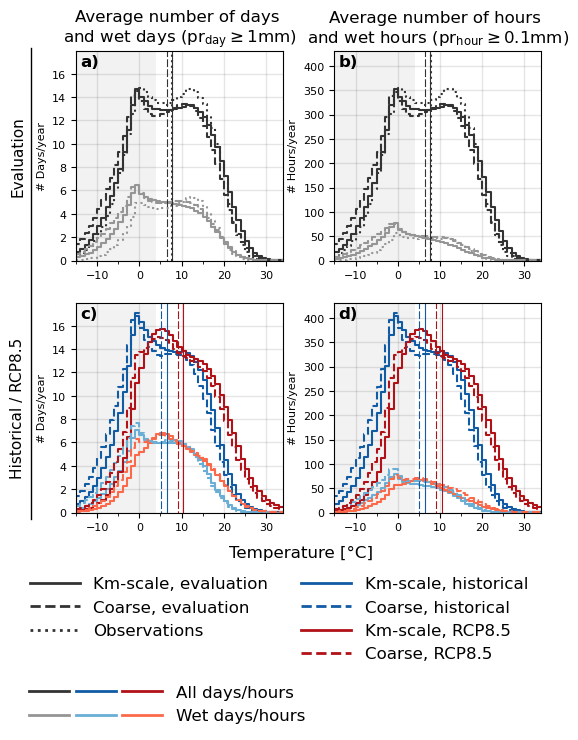

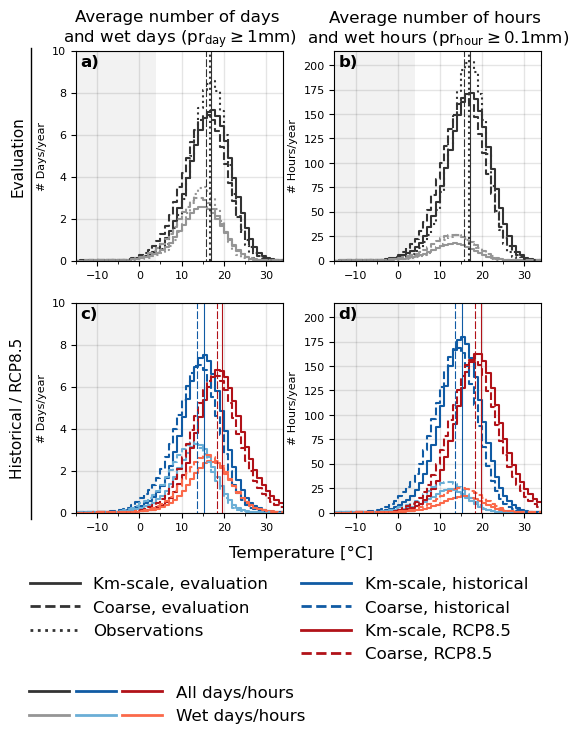

In [69]:
# for season in ['allseasons', 'DJF', 'MAM', 'JJA', 'SON']:
for season, figname in zip(['allseasons', 'JJA'], ["Fig_S2", "Fig_S3"]):
    # normalization factor: number of days/hours per year/season differs
    if season == 'allseasons':
        normalization_factor_days = normalization_factor_days_year
        normalization_factor_hours = normalization_factor_hours_year
    else:
        normalization_factor_days = normalization_factor_days_season
        normalization_factor_hours = normalization_factor_hours_season
        
    # initiate figure
    fig, axes = plt.subplots(
    ncols=2,
    nrows=2,
    sharex=True,
    sharey='col',
    figsize=[6, 6]
    )

    # FIRST ROW: evaluation
    for res, ls in zip(["stations", "kmscale", "driving"], [ls_stations, ls_kmscale, ls_driving]):
        plot_normalized_frequency_step(
            dict_ds_noreq[f"ds_quantiles_{res}_eval_ddmean_{season}"],
            axes[0, 0],
            ls=ls,
            color_primary=c1_eval,
            color_secondary=c3_eval,
            normalization_factor=normalization_factor_days,
        )
        plot_normalized_frequency_step(
            dict_ds_noreq[f"ds_quantiles_{res}_eval_hdmean_{season}"],
            axes[0, 1],
            ls=ls,
            color_primary=c1_eval,
            color_secondary=c3_eval,
            normalization_factor=normalization_factor_hours,
        )
        
    axes[0, 0].set_title('Average number of days \nand wet days ($pr_{day} \\geq 1mm$)')
    axes[0, 1].set_title('Average number of hours \nand wet hours ($pr_{hour} \\geq0.1mm$)')

    # SECOND ROW: hist + rcp
    for res, ls in zip(["kmscale", "driving"], [ls_kmscale, ls_driving]):
        plot_normalized_frequency_step(
            dict_ds_noreq[f"ds_quantiles_{res}_hist_ddmean_{season}"],
            axes[1, 0],
            ls=ls,
            color_primary=c1_hist,
            color_secondary=c3_hist,
            normalization_factor=normalization_factor_days,
        )
        plot_normalized_frequency_step(
            dict_ds_noreq[f"ds_quantiles_{res}_hist_hdmean_{season}"],
            axes[1, 1],
            ls=ls,
            color_primary=c1_hist,
            color_secondary=c3_hist,
            normalization_factor=normalization_factor_hours,
        )
        plot_normalized_frequency_step(
            dict_ds_noreq[f"ds_quantiles_{res}_rcp_ddmean_{season}"],
            axes[1, 0],
            ls=ls,
            color_primary=c1_rcp,
            color_secondary=c3_rcp,
            normalization_factor=normalization_factor_days,
        )
        plot_normalized_frequency_step(
            dict_ds_noreq[f"ds_quantiles_{res}_rcp_hdmean_{season}"],
            axes[1, 1],
            ls=ls,
            color_primary=c1_rcp,
            color_secondary=c3_rcp,
            normalization_factor=normalization_factor_hours,
        )
            
    # change axes settings
    for ax in axes.flatten():
        if ax.get_ylim()[1] < 10:
            ax.set_ylim(0, 10)
        else:
            ax.set_ylim(0, None)
        ax.set_xlim(xlim_fullrange)
        # ax.set_ylabel('')
        ax.set_xlabel('')
        decorate_axis(ax)

    # add subplot labels: letters in the upper left corner
    for ax, letter in zip(axes.flatten(), string.ascii_lowercase):
        ax.text(0.02, 0.98, f'{letter})', transform=ax.transAxes,
        fontweight='bold', va='top')

    axes[0, 0].set_ylabel('# Days/year')
    axes[1, 0].set_ylabel('# Days/year')
    axes[0, 1].set_ylabel('# Hours/year')
    axes[1, 1].set_ylabel('# Hours/year')

    x = -0.32
    axes[0, 0].text(x, 0.5, 'Evaluation', rotation=90, transform=axes[0, 0].transAxes, va='center', fontsize=fontsize-1)
    axes[1, 0].text(x, 0.5, 'Historical / RCP8.5', rotation=90, transform=axes[1, 0].transAxes, va='center', fontsize=fontsize-1)

    fig.supxlabel("Temperature [°C]", y=0.03)

    # add mean temperature lines for all datasets
    longdash = (5, (7, 2))
    for ax in axes[0, :]:
        ax.axvline(
            x=get_mean_temperature(dict_ds_noreq[f"ds_quantiles_stations_eval_ddmean_{season}"]),
            color=c1_eval, lw=1.5, ls=":",
        )
        ax.axvline(
            x=get_mean_temperature(dict_ds_noreq[f"ds_quantiles_kmscale_eval_ddmean_{season}"]),
            color=c1_eval, lw=0.8, ls="-",
        )
        ax.axvline(
            x=get_mean_temperature(dict_ds_noreq[f"ds_quantiles_driving_eval_ddmean_{season}"]),
            color=c1_eval, lw=0.8, ls=longdash,
        )

    for ax in axes[1, :]:
        ax.axvline(
            x=get_mean_temperature(dict_ds_noreq[f"ds_quantiles_kmscale_hist_ddmean_{season}"]),
            color=c1_hist, lw=0.8, ls="-",
        )
        ax.axvline(
            x=get_mean_temperature(dict_ds_noreq[f"ds_quantiles_driving_hist_ddmean_{season}"]),
            color=c1_hist, lw=0.8, ls=longdash,
        )
        ax.axvline(
            x=get_mean_temperature(dict_ds_noreq[f"ds_quantiles_kmscale_rcp_ddmean_{season}"]),
            color=c1_rcp, lw=0.8, ls="-",
        )
        ax.axvline(
            x=get_mean_temperature(dict_ds_noreq[f"ds_quantiles_driving_rcp_ddmean_{season}"]),
            color=c1_rcp, lw=0.8, ls=longdash,
        )

    # LEGENDS
    # add a "None" line to the legend to make it align nicely
    handles_all_noneline = handles_all_datasets.copy()
    line_None = mpl.lines.Line2D([], [], color='w', lw=lw_legend, linestyle='-',  label='')
    handles_all_noneline.insert(3, line_None)
    # legend: all lines
    axes[-1, -1].legend(
        handles=handles_all_noneline,
        bbox_to_anchor=[-1.53, -0.25],
        borderpad=0.2,
        ncol=2,
        handlelength=3,
        frameon=False,
        loc='upper left')

    axes[-1, 0].legend(
        handles_all_wet_days_hours,
        ['All days/hours', 'Wet days/hours'],
        bbox_to_anchor=[-0.3, -0.75], 
        loc='upper left', 
        frameon=False, 
        ncol=1, 
        handlelength=8, 
        handler_map={tuple: mpl.legend_handler.HandlerTuple(ndivide=None)})

    # add vertical line in the left side of the plot
    x = 0.05
    fig.add_artist(plt.Line2D([x, x], [0.1, 0.885], transform=fig.transFigure,
                  color='k', linestyle='-', linewidth=1))

    fig.subplots_adjust(wspace=0.25)

    if savefigs:
        fig.savefig(os.path.join(folder_figures, f'{figname}.pdf'),
            dpi=200,
            bbox_inches='tight',
            format='pdf')

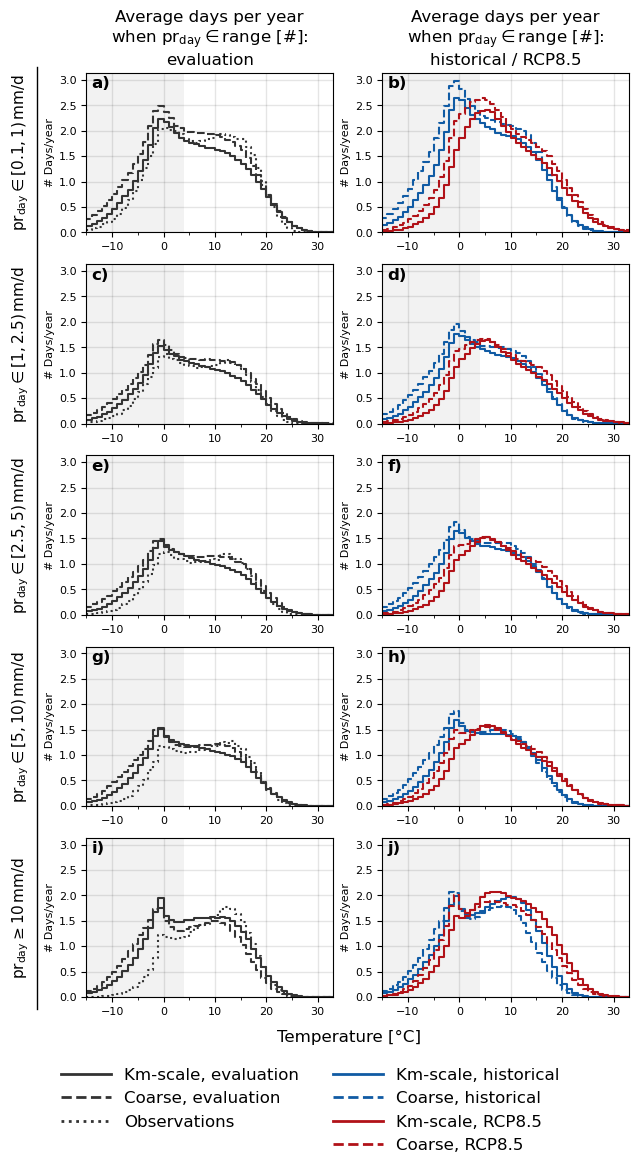

In [70]:
fig, axes = plt.subplots(
    nrows=len(dict_pr_ranges),
    ncols=2,
    sharey=True,
    sharex=True,
    figsize=[7, 12]
)

datasets = [
    (ds_kmscale_eval_req, ds_kmscale_eval_noreq, ls_kmscale, c1_eval, c2_eval, c3_eval, 'Km-scale: evaluation'),
    (ds_driving_eval_req, ds_driving_eval_noreq, ls_driving, c1_eval, c2_eval, c3_eval, 'Coarse: evaluation'),
    (ds_stations_eval_req, ds_stations_eval_noreq, ls_stations, c1_eval, c2_eval, c3_eval, 'Observations: evaluation'),
    (ds_kmscale_hist_req, ds_kmscale_hist_noreq, ls_kmscale, c1_hist, c2_hist, c3_hist, 'Km-scale: historical'),
    (ds_driving_hist_req, ds_driving_hist_noreq, ls_driving, c1_hist, c2_hist, c3_hist, 'Coarse: historical'),
    (ds_kmscale_rcp_req, ds_kmscale_rcp_noreq, ls_kmscale, c1_rcp, c2_rcp, c3_rcp, 'Km-scale: RCP8.5'),
    (ds_driving_rcp_req, ds_driving_rcp_noreq, ls_driving, c1_rcp, c2_rcp, c3_rcp, 'Coarse: RCP8.5'),
    ]

# plot all lines in all plots for easier comparison? 
#   lines corresponding to other panels would be plotted in thin lines
plot_thin_lines = False

for r_idx, (r, r_label) in enumerate(zip(dict_pr_ranges.keys(), dict_pr_ranges.values())):
    var_full = f'pr_range_count_{r}'

    for (ds, ds_noreq, ls, c_primary, c_daily, c_hourly, label) in datasets:
        if 'evaluation' in label:
            c_idx = 0
        else:
            c_idx = 1
        dims = [dim for dim in ["model", "station_name"] if dim in ds_noreq.dims]

        plot_pr_range_count_step(
            ds_noreq, dims, var_full, axes[r_idx, c_idx], ls, c_primary,
            normalization_factor=normalization_factor_days_year,
            label=label,
        )

        if plot_thin_lines:
            for ax in axes[:, c_idx]:
                plot_pr_range_count_step(
                    ds_noreq, dims, var_full, ax, ls, c_primary,
                    normalization_factor=normalization_factor_days_year,
                    lw=lw_thin, 
                    alpha=alpha,
                )


# axes settings etc of both figures
for ax in axes.flatten():
    ax.set_xlim(-15, 33)
    ax.set_ylim(0, None)
    ax.set_xlabel('')
    ax.set_ylabel("# Days/year", labelpad=2.5)
    decorate_axis(ax)

# set text as y-labels with larger font
pr_range_labels = [
    '$\\in [0.1, 1)\\,mm/d$',
    '$\\in [1, 2.5)\\,mm/d$',
    '$\\in [2.5, 5)\\,mm/d$',
    '$\\in [5, 10)\\,mm/d$', 
    '$\\geq 10\\,mm/d$'
]    
for ax, pr_range in zip(axes[:, 0], pr_range_labels):
    # determine text for the y-axis
    text = '$pr_{day}$'+f'{pr_range}'
    # add labels and/or units to each y-axis
    ax.text(-0.31, 0.5, text, rotation=90, transform=ax.transAxes, va='center', fontsize=fontsize-1)    

# set labels
axes[0, 0].set_title('Average days per year\nwhen $pr_{day} \\in range$ [#]:\nevaluation')
axes[0, 1].set_title('Average days per year\nwhen $pr_{day} \\in range$ [#]:\nhistorical / RCP8.5')

# add subplot labels: letters in the upper left corner
for ax, letter in zip(axes.flatten(), string.ascii_lowercase+string.ascii_uppercase):
    ax.text(0.02, 0.98, f'{letter})', transform=ax.transAxes,
    fontweight='bold', va='top')

# add legend
axes[-1, -1].legend(
    handles=handles_all_noneline,
    bbox_to_anchor=[-1.35, -0.37],
    borderpad=0.2,
    ncol=2,
    handlelength=3,
    frameon=False,
    loc='upper left')

fig.supxlabel("Temperature [°C]", y=0.07)

# add vertical line in the left side of the plot
x = 0.055
fig.add_artist(plt.Line2D([x, x], [0.1, 0.885], transform=fig.transFigure,
                color='k', linestyle='-', linewidth=1))

# save figure
if savefigs:
    fig.savefig(os.path.join(folder_figures, 'Fig_S6.pdf'),
        dpi=200,
        bbox_inches='tight',
        format='pdf')



# Figure BLAH: Sensitivity to thresholds

In [71]:
# create dictionaries with different fractional requirements
# Load all data into a dictionary: apply requirements

# Original, more detailed sensitivity ananlysis
# req_counts    = [0,    1200, 2400, 2400, 2400, 2400, 2400, 2400, 2400]
# frac_stations = [0.0,  0.0,  0.0,  0.1,  0.2,  0.2,  0.2,  0.3,  0.3 ]
# frac_models   = [0.0,  0.0,  0.0,  0.0,  0.0,  0.1,  0.2,  0.0,  0.3 ]

# Reduced sensitivity analysis
req_counts    = [0,    1200, 2400, 2400, 2400]
frac_stations = [0.0,  0.0,  0.0,  0.2,  0.2]
frac_models   = [0.0,  0.0,  0.0,  0.0,  0.2]

# this will be a dict of dicts for the various requirement combinations
dict_fractions = {}
dict_fractions_weighted = {}

# loop through various required fractions
for dict_num, (req_count, frac_station, frac_model) in enumerate(zip(req_counts, frac_stations, frac_models)):
    print(dict_num)
    # calculate required days and hours
    req_count_hours_year = req_count
    req_count_days_year = int(req_count / 24)
    # define a base dictionary with the corresponding fraction for both stations and models
    kwargs_req_base = {}
    kwargs_req_base = dict(
        requirements=True,
        req_station_fraction=frac_station,
        req_model_fraction=frac_model
    )

    # define keys and values specific to individual datasets
    # use dictionary unpacking to propagate the base values among all subsequent dictionaries
    kwargs_req_quantiles_days_year    = {**kwargs_req_base,  'req_count': req_count_days_year,     'count_var': 'count_all'}
    kwargs_req_quantiles_hours_year   = {**kwargs_req_base,  'req_count': req_count_hours_year,    'count_var': 'count_all'}
    kwargs_req_daystats_year          = {**kwargs_req_base,  'req_count': req_count_days_year,     'count_var': 'daily_count'}

    # create empty dictionaries for simple/weighted means
    dictionary_one_frac = {}
    dictionary_one_frac_weighted = {}
    
    # get simple mean: stations
    dictionary_one_frac["ds_quantiles_stations_eval_hdmean_allseasons"] = open_and_prepare_dataset(f"{folder_processed_data}/quantiles_GeoSphere_eval_hdmean_allseasons.nc", apply_req=True, get_mean=True, **kwargs_req_quantiles_hours_year)
    dictionary_one_frac["ds_quantiles_stations_eval_ddmean_allseasons"] = open_and_prepare_dataset(f"{folder_processed_data}/quantiles_GeoSphere_eval_ddmean_allseasons.nc", apply_req=True, get_mean=True, **kwargs_req_quantiles_days_year)
    dictionary_one_frac["ds_daystats_stations_eval_dmean_allseasons"] = open_and_prepare_dataset(f"{folder_processed_data}/various_daily_stats_GeoSphere_eval_dmean_allseasons.nc", apply_req=True, get_mean=True, **kwargs_req_daystats_year)
    # ge weighted mean: stations
    dictionary_one_frac_weighted["ds_quantiles_stations_eval_hdmean_allseasons"] = open_and_prepare_dataset(f"{folder_processed_data}/quantiles_GeoSphere_eval_hdmean_allseasons.nc", apply_req=True, get_mean_weighted=True, **kwargs_req_quantiles_hours_year)
    dictionary_one_frac_weighted["ds_quantiles_stations_eval_ddmean_allseasons"] = open_and_prepare_dataset(f"{folder_processed_data}/quantiles_GeoSphere_eval_ddmean_allseasons.nc", apply_req=True, get_mean_weighted=True, **kwargs_req_quantiles_days_year)
    dictionary_one_frac_weighted["ds_daystats_stations_eval_dmean_allseasons"] = open_and_prepare_dataset(f"{folder_processed_data}/various_daily_stats_GeoSphere_eval_dmean_allseasons.nc", apply_req=True, get_mean_weighted=True, **kwargs_req_daystats_year)


    # fill with the fraction being applied without taking means (that takes means over all variables which takes ages)
    for res in ["kmscale", "driving"]:
        # get simple mean
        dictionary_one_frac[f"ds_quantiles_{res}_eval_hdmean_allseasons"] = open_and_prepare_dataset(f"{folder_processed_data}/quantiles_{res}_ensemble_eval_hdmean_allseasons.nc", apply_req=True, get_mean=True, **kwargs_req_quantiles_hours_year)
        dictionary_one_frac[f"ds_quantiles_{res}_eval_ddmean_allseasons"] = open_and_prepare_dataset(f"{folder_processed_data}/quantiles_{res}_ensemble_eval_ddmean_allseasons.nc", apply_req=True, get_mean=True, **kwargs_req_quantiles_days_year)
        dictionary_one_frac[f"ds_daystats_{res}_eval_dmean_allseasons"] = open_and_prepare_dataset(f"{folder_processed_data}/various_daily_stats_{res}_ensemble_eval_dmean_allseasons.nc", apply_req=True, get_mean=True, **kwargs_req_daystats_year)
        # ge weighted mean
        dictionary_one_frac_weighted[f"ds_quantiles_{res}_eval_hdmean_allseasons"] = open_and_prepare_dataset(f"{folder_processed_data}/quantiles_{res}_ensemble_eval_hdmean_allseasons.nc", apply_req=True, get_mean_weighted=True, **kwargs_req_quantiles_hours_year)
        dictionary_one_frac_weighted[f"ds_quantiles_{res}_eval_ddmean_allseasons"] = open_and_prepare_dataset(f"{folder_processed_data}/quantiles_{res}_ensemble_eval_ddmean_allseasons.nc", apply_req=True, get_mean_weighted=True, **kwargs_req_quantiles_days_year)
        dictionary_one_frac_weighted[f"ds_daystats_{res}_eval_dmean_allseasons"] = open_and_prepare_dataset(f"{folder_processed_data}/various_daily_stats_{res}_ensemble_eval_dmean_allseasons.nc", apply_req=True, get_mean_weighted=True, **kwargs_req_daystats_year)

    # nest the created dictionary in a dict of dicts
    dict_str = f'dict_ds_req_{dict_num}'
    dict_fractions[dict_str] = dictionary_one_frac
    dict_fractions_weighted[dict_str] = dictionary_one_frac_weighted

0


1
2
3
4


In [72]:
# Figure for reviewer: compare weighted vs unweighted results
# Only the requirements that we actually used
dict_fractions_unweighted_vs_weighted = {}

# required days and hours
req_count_hours_year = 2400
req_count_days_year = int(req_count / 24)
# define a base dictionary with the corresponding fraction for both stations and models
kwargs_req_base = {}
kwargs_req_base = dict(
    requirements=True,
    req_station_fraction=0.2,
    req_model_fraction=0.2
)

# define keys and values specific to individual datasets
# use dictionary unpacking to propagate the base values among all subsequent dictionaries
kwargs_req_quantiles_days_year    = {**kwargs_req_base,  'req_count': req_count_days_year,     'count_var': 'count_all'}
kwargs_req_quantiles_hours_year   = {**kwargs_req_base,  'req_count': req_count_hours_year,    'count_var': 'count_all'}
kwargs_req_daystats_year          = {**kwargs_req_base,  'req_count': req_count_days_year,     'count_var': 'daily_count'}

# create empty dictionaries for simple/weighted means
dict_unweighted = {}
dict_weighted = {}

# get simple mean: stations
dict_unweighted["ds_quantiles_stations_eval_hdmean_allseasons"] = open_and_prepare_dataset(f"{folder_processed_data}/quantiles_GeoSphere_eval_hdmean_allseasons.nc", apply_req=True, get_mean=True, **kwargs_req_quantiles_hours_year)
dict_unweighted["ds_quantiles_stations_eval_ddmean_allseasons"] = open_and_prepare_dataset(f"{folder_processed_data}/quantiles_GeoSphere_eval_ddmean_allseasons.nc", apply_req=True, get_mean=True, **kwargs_req_quantiles_days_year)
dict_unweighted["ds_daystats_stations_eval_dmean_allseasons"] = open_and_prepare_dataset(f"{folder_processed_data}/various_daily_stats_GeoSphere_eval_dmean_allseasons.nc", apply_req=True, get_mean=True, **kwargs_req_daystats_year)
# ge weighted mean: stations
dict_weighted["ds_quantiles_stations_eval_hdmean_allseasons"] = open_and_prepare_dataset(f"{folder_processed_data}/quantiles_GeoSphere_eval_hdmean_allseasons.nc", apply_req=True, get_mean_weighted=True, **kwargs_req_quantiles_hours_year)
dict_weighted["ds_quantiles_stations_eval_ddmean_allseasons"] = open_and_prepare_dataset(f"{folder_processed_data}/quantiles_GeoSphere_eval_ddmean_allseasons.nc", apply_req=True, get_mean_weighted=True, **kwargs_req_quantiles_days_year)
dict_weighted["ds_daystats_stations_eval_dmean_allseasons"] = open_and_prepare_dataset(f"{folder_processed_data}/various_daily_stats_GeoSphere_eval_dmean_allseasons.nc", apply_req=True, get_mean_weighted=True, **kwargs_req_daystats_year)


# fill with the fraction being applied without taking means (that takes means over all variables which takes ages)
for res in ["kmscale", "driving"]:
    # get simple mean
    dict_unweighted[f"ds_quantiles_{res}_eval_hdmean_allseasons"] = open_and_prepare_dataset(f"{folder_processed_data}/quantiles_{res}_ensemble_eval_hdmean_allseasons.nc", apply_req=True, get_mean=True, **kwargs_req_quantiles_hours_year)
    dict_unweighted[f"ds_quantiles_{res}_eval_ddmean_allseasons"] = open_and_prepare_dataset(f"{folder_processed_data}/quantiles_{res}_ensemble_eval_ddmean_allseasons.nc", apply_req=True, get_mean=True, **kwargs_req_quantiles_days_year)
    dict_unweighted[f"ds_daystats_{res}_eval_dmean_allseasons"] = open_and_prepare_dataset(f"{folder_processed_data}/various_daily_stats_{res}_ensemble_eval_dmean_allseasons.nc", apply_req=True, get_mean=True, **kwargs_req_daystats_year)
    # ge weighted mean
    dict_weighted[f"ds_quantiles_{res}_eval_hdmean_allseasons"] = open_and_prepare_dataset(f"{folder_processed_data}/quantiles_{res}_ensemble_eval_hdmean_allseasons.nc", apply_req=True, get_mean_weighted=True, **kwargs_req_quantiles_hours_year)
    dict_weighted[f"ds_quantiles_{res}_eval_ddmean_allseasons"] = open_and_prepare_dataset(f"{folder_processed_data}/quantiles_{res}_ensemble_eval_ddmean_allseasons.nc", apply_req=True, get_mean_weighted=True, **kwargs_req_quantiles_days_year)
    dict_weighted[f"ds_daystats_{res}_eval_dmean_allseasons"] = open_and_prepare_dataset(f"{folder_processed_data}/various_daily_stats_{res}_ensemble_eval_dmean_allseasons.nc", apply_req=True, get_mean_weighted=True, **kwargs_req_daystats_year)

dict_fractions_unweighted_vs_weighted['unweighted'] = dict_unweighted
dict_fractions_unweighted_vs_weighted['weighted'] = dict_weighted



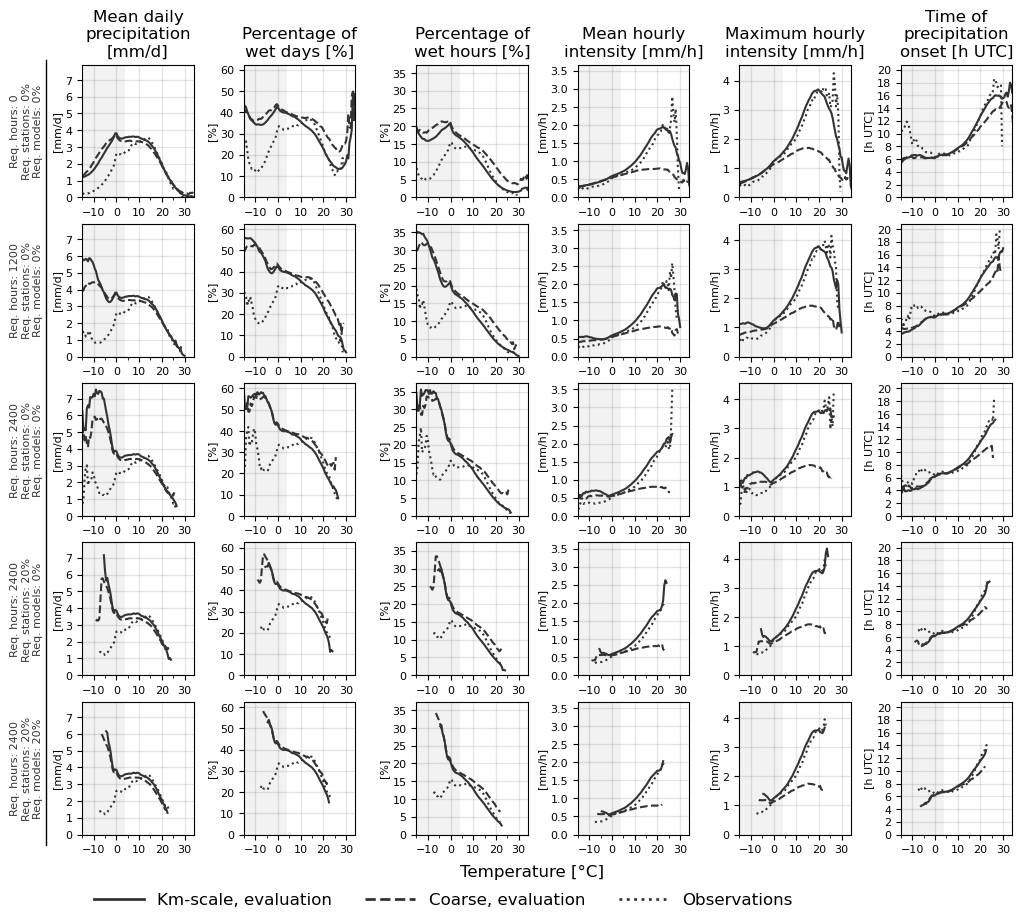

In [73]:
for dict_frac in [dict_fractions, dict_fractions_weighted][:1]:
    rows = len(dict_frac)
    # use gridspec to add whitespace (narrow, empty axis) between the daily and the hourly subplots
    # second gap bigger: empty space between the daily and the hourly subplots
    gap = 0.45
    width_ratios = [1, gap, 1, gap+0.1, 1, gap, 1, gap, 1, gap, 1]
    gs = mpl.gridspec.GridSpec(rows, 11, width_ratios=width_ratios, wspace=0)

    # initiate figure without axes
    fig = plt.figure(figsize=[12, 10])

    # create a placeholder array to hold the axes that will be added to the figure according to the gridspec
    axes = np.empty((rows, 6),  dtype=object)
    # we want 5 rows, 6 columns
    for i in range(rows):
        for j in range(6): 
            # Skip the empty placeholder axes used to create empty spaces
            gs_col = j * 2
            # Share y-axis limits with the first row
            if i == 0:
                share_ax = None
            else:
                share_ax = axes[0, j]

            # add axis to the figure according to gridspec
            ax = fig.add_subplot(gs[i, gs_col], sharey=share_ax)
            # add the created axis to the axes array
            axes[i, j] = ax

    # now that axes are created, start plotting
    for row_idx, (dict_key, dictionary) in enumerate(list(dict_frac.items())):
        for res, ls in zip(["stations", "kmscale", "driving"], [ls_stations, ls_kmscale, ls_driving]):
            dims = [dim for dim in dictionary[f"ds_quantiles_{res}_eval_ddmean_allseasons"].dims if dim in ["station_name", "model"]]
            dictionary[f"ds_quantiles_{res}_eval_ddmean_allseasons"]["wet_percentage"].plot(ax=axes[row_idx, 1], ls=ls, c=c1_eval)
            dictionary[f"ds_quantiles_{res}_eval_hdmean_allseasons"]["wet_percentage"].plot(ax=axes[row_idx, 2], ls=ls, c=c1_eval)

            # Columns 1, 4, 5, 6: mean daily precipitation, mean daily intensity, max daily intensity, time of precipitation onset
            for (v, i) in zip(vars_alldays, [0, 3, 4, 5]):
                dictionary[f"ds_daystats_{res}_eval_dmean_allseasons"][v].plot(ax=axes[row_idx, i], ls=ls, color=c1_eval)

    # Change axes settings: ranges, ticks, labels, etc
    for ax in axes.flatten():
        ax.set_ylim(0, None)
        ax.set_xlim(xlim_fullrange)
        ax.set_xlabel("")
        decorate_axis(ax)

    # set titles, x- and y-labels of the columns: others are set before
    for ax, title in zip(axes[0, :], titles_alldays):
        ax.set_title(title) 

    unit_labels = ['[mm/d]', '[%]', '[%]', '[mm/h]', '[mm/h]', '[h UTC]']
    major_ticks = [1, 10, 5, 0.5, 1, 2]
    labelpad = 2.3
    for ax_idx, (unit, tick) in enumerate(zip(unit_labels, major_ticks)):
        for ax in axes[:, ax_idx]:
            # add units to each y-axis
            ax.set_ylabel(unit, labelpad=labelpad)
            # determine major y-ticks for every subplot
            ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=tick))

    fig.supxlabel("Temperature [°C]", y=0.065)

    # add text to the first column 
    for ax, req_count, frac_station, frac_model in zip(axes[:, 0], req_counts, frac_stations, frac_models):

        # determine text for the y-axis
        text = f'Req. hours: {req_count}\nReq. stations: {100*frac_station:.0f}%\nReq. models: {100*frac_model:.0f}%'
        ax.text(-0.5, 0.5, text, rotation=90, transform=ax.transAxes, va='center', ha='center', fontsize=fontsize_small, c=c1_eval)

    # add vertical line in the left side of the plot
    x = 0.095
    fig.add_artist(plt.Line2D([x, x], [0.1, 0.885], transform=fig.transFigure,
                    color='k', linestyle='-', linewidth=1))

    # legend
    axes[-1, 0].legend(
        handles=handles_all_datasets[:3],
        bbox_to_anchor=[0, -0.35],
        borderpad=0.2,
        ncol=3,
        handlelength=3,
        frameon=False,
        loc="upper left");

    plt.show()


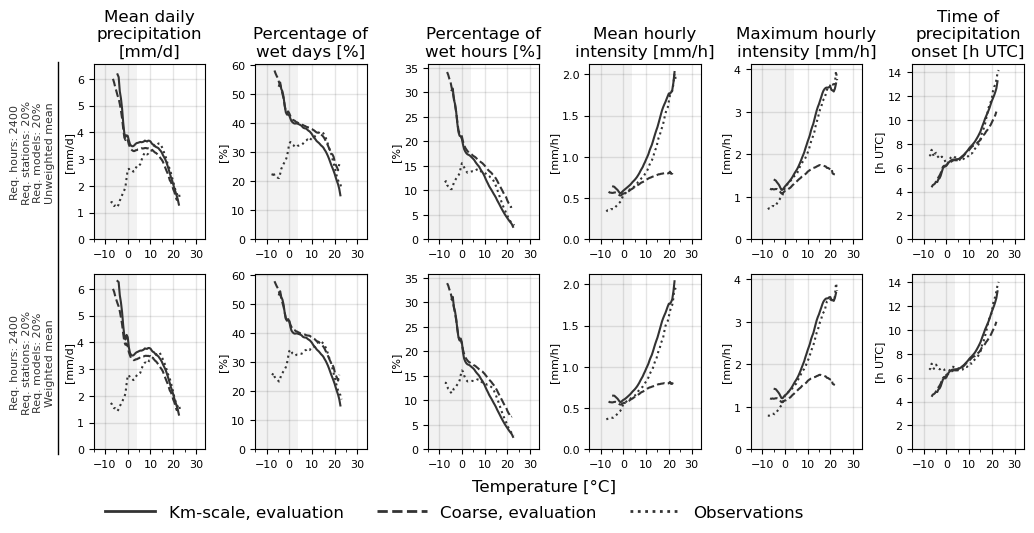

In [74]:
for dict_frac in [dict_fractions_unweighted_vs_weighted, ]:
    rows = len(dict_frac)
    # use gridspec to add whitespace (narrow, empty axis) between the daily and the hourly subplots
    # second gap bigger: empty space between the daily and the hourly subplots
    gap = 0.45
    width_ratios = [1, gap, 1, gap+0.1, 1, gap, 1, gap, 1, gap, 1]
    gs = mpl.gridspec.GridSpec(rows, 11, width_ratios=width_ratios, wspace=0)

    # initiate figure without axes
    fig = plt.figure(figsize=[12, 5])

    # create a placeholder array to hold the axes that will be added to the figure according to the gridspec
    axes = np.empty((rows, 6),  dtype=object)
    # we want 5 rows, 6 columns
    for i in range(rows):
        for j in range(6): 
            # Skip the empty placeholder axes used to create empty spaces
            gs_col = j * 2
            # Share y-axis limits with the first row
            if i == 0:
                share_ax = None
            else:
                share_ax = axes[0, j]

            # add axis to the figure according to gridspec
            ax = fig.add_subplot(gs[i, gs_col], sharey=share_ax)
            # add the created axis to the axes array
            axes[i, j] = ax

    # now that axes are created, start plotting
    for row_idx, (dict_key, dictionary) in enumerate(list(dict_frac.items())):
        for res, ls in zip(["stations", "kmscale", "driving"], [ls_stations, ls_kmscale, ls_driving]):
            dims = [dim for dim in dictionary[f"ds_quantiles_{res}_eval_ddmean_allseasons"].dims if dim in ["station_name", "model"]]
            dictionary[f"ds_quantiles_{res}_eval_ddmean_allseasons"]["wet_percentage"].plot(ax=axes[row_idx, 1], ls=ls, c=c1_eval)
            dictionary[f"ds_quantiles_{res}_eval_hdmean_allseasons"]["wet_percentage"].plot(ax=axes[row_idx, 2], ls=ls, c=c1_eval)

            # Columns 1, 4, 5, 6: mean daily precipitation, mean daily intensity, max daily intensity, time of precipitation onset
            for (v, i) in zip(vars_alldays, [0, 3, 4, 5]):
                dictionary[f"ds_daystats_{res}_eval_dmean_allseasons"][v].plot(ax=axes[row_idx, i], ls=ls, color=c1_eval)

    # Change axes settings: ranges, ticks, labels, etc
    for ax in axes.flatten():
        ax.set_ylim(0, None)
        ax.set_xlim(xlim_fullrange)
        ax.set_xlabel("")
        decorate_axis(ax)

    # set titles, x- and y-labels of the columns: others are set before
    for ax, title in zip(axes[0, :], titles_alldays):
        ax.set_title(title) 

    unit_labels = ['[mm/d]', '[%]', '[%]', '[mm/h]', '[mm/h]', '[h UTC]']
    major_ticks = [1, 10, 5, 0.5, 1, 2]
    labelpad = 2.3
    for ax_idx, (unit, tick) in enumerate(zip(unit_labels, major_ticks)):
        for ax in axes[:, ax_idx]:
            # add units to each y-axis
            ax.set_ylabel(unit, labelpad=labelpad)
            # determine major y-ticks for every subplot
            ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=tick))

    fig.supxlabel("Temperature [°C]", y=0.02)

    # add text to the first column 
    for ax, weight_str in zip(axes[:, 0], ['Unweighted mean', 'Weighted mean']):
        # determine text for the y-axis
        text = f'Req. hours: 2400\nReq. stations: 20%\nReq. models: 20%\n{weight_str}'
        ax.text(-0.55, 0.5, text, rotation=90, transform=ax.transAxes, va='center', ha='center', fontsize=fontsize_small, c=c1_eval)

    # add vertical line in the left side of the plot
    x = 0.095
    fig.add_artist(plt.Line2D([x, x], [0.1, 0.885], transform=fig.transFigure,
                    color='k', linestyle='-', linewidth=1))

    # legend
    axes[-1, 0].legend(
        handles=handles_all_datasets[:3],
        bbox_to_anchor=[0, -0.25],
        borderpad=0.2,
        ncol=3,
        handlelength=3,
        frameon=False,
        loc="upper left");

    plt.show()


# Tests

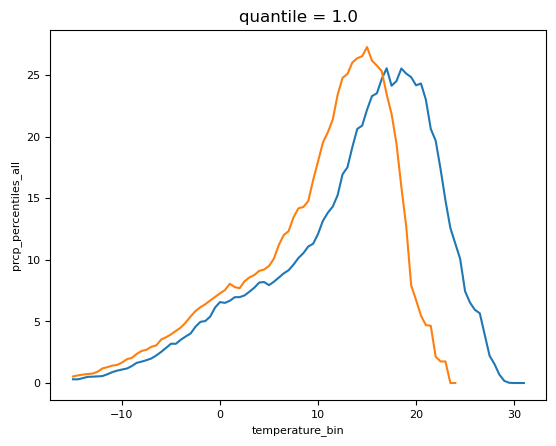

In [75]:
ds_tas = xr.open_dataset("/gpfs/data/fs71966/amedvedova/publication_data/processed_data/quantiles_GeoSphere_eval_hdmean_allseasons.nc") #.mean(dim="station_name")

ds_td = xr.open_dataset("/gpfs/data/fs71966/amedvedova/publication_data/processed_data/quantiles_GeoSphere_eval_hdmean_allseasons_td.nc") #.mean(dim="station_name")
ds_tas.prcp_percentiles_all.mean(dim="station_name").isel(quantile=-1).plot()
ds_td.prcp_percentiles_all.mean(dim="station_name").isel(quantile=-1).plot()